In [4]:
#import scarches as sca
import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os
import time
import pickle
from itertools import chain
import itertools
from tqdm.auto import tqdm
import anndata as ad
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
from scipy.stats import zscore
from PIL import Image

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# FUNCTIONS

In [5]:

def create_celltype_cluster_colormap(adata,color_var,high_level_celltypes_coln,low_level_celltypes_coln):
    
    ## CREATE CLUSTER COLORING
    #clusters=np.sort(adata.obs[color_var].unique()) #cellt_freq_df.reset_index()[color_var] 
    
    # Extract cell types from cluster names
    #cell_types = adata.obs[high_level_celltypes_coln].replace({'Macrophage':'Mac'}).unique().tolist()#np.unique([c.split('_')[0] for c in clusters])
    #print(cell_types)
    high_low_level_dict=pd.crosstab(adata.obs[high_level_celltypes_coln].replace({'Macrophage/Neutrophil':'Macrophage'},regex=True),\
                                    adata.obs[low_level_celltypes_coln]).T.apply(lambda x:x[x>0].index.tolist()).to_dict()
    
    # Assign a base color to each cell type
    base_colors = sns.color_palette('tab10', len(high_low_level_dict.keys()))
    cell_type_color_mapping = dict(zip([*high_low_level_dict], base_colors))
    
    lightness_threshold=1
    
    # Create the final color mapping
    clusters_color_mapping = {}
    #for cell_type in cell_types:
    for high_level_celltype in [*high_low_level_dict]:
        #print('high_level_celltype',high_level_celltype)
        
        # Get all clusters for the current cell type
        #cell_type_clusters = [c for c in clusters if c.startswith(cell_type)]
        low_level_celltypes=high_low_level_dict[high_level_celltype]
    
        if len(low_level_celltypes)>1:
    
            # Create a blended palette for the current cell type
            shades = sns.blend_palette([cell_type_color_mapping[high_level_celltype], (1, 1, 1)], 
                                       n_colors=(len(low_level_celltypes)+1), as_cmap=False, input="rgb")
            '''
            # Adjust the lightness of the lightest color
            shades = [(max(min(color[0], lightness_threshold), 0), 
                       max(min(color[1], lightness_threshold), 0), 
                       max(min(color[2], lightness_threshold), 0)) for color in shades]
            '''
            
            # Assign shades to clusters
            for i, cluster in enumerate(low_level_celltypes):
                clusters_color_mapping[cluster] = shades[i]
        
        if len(low_level_celltypes)==1:
            clusters_color_mapping[high_level_celltype] = cell_type_color_mapping[high_level_celltype]
    return clusters_color_mapping


##### =============================================
## Based on the annotated low-level celltypes, add a new column to adata.obs with the final high-level celltypes
#  (as one Macrophage cluster was given Neutrophil in the high-level clustering in xen_4_manual_annotation.ipynb)
def add_celltype_as_prefix(adata_,annotation_coln):

    bdata=adata_.copy()
    
    celltype_dict={'Macrophage':['Mac_4',
                                'Mac_5',
                                'Mac_3',

                                 'Mac_C1Q',
                                 'Mac_HMOX1',
                                 'Mac_IL10',
                                 'Mac_TREM2',

                                 'C1Q', 
                                 'HMOX1',
                                 'IFN_resp.', 
                                 'IL10+/TNFAIP3+', 
                                
                                 'PLIN2hi/TREM1hi',
                                 'S100A8/IL1B+', 
                                 'S100A8/IL1B-', 
                                 'TREM2hi'],
                   
                   'T-cell':[
                               'CD4_Exh.', 
                              'CD4_TCM', 
                              'CD4_TEM',
                              'CD4_Tregs', 
                              'CD8_IFN_resp.',
                              'CD8_TEFF', 
                              'CD8_TEM', 
                              'MAIT',
                              'Proliferating',
                               'Unknown',
                                'Teff-cell'],
                   
                   
                   'B2-cell':['B2-cell'],

                   'Neutrophil':['Neutrophil'],
                   
                   'Endothelial':['EC_1',
                                  'EC_2'],

                   'Plasma-cell':['Plasma-cell'],

                   'Mast-cell':['Mast-cell'],
                
                   
                   'VSMC':['VSMC-contr', 
                            'VSMC-synth', 
                            'VSMC-foam', 
                            'VSMC-macrophage-like', 
                            'VSMC-adipocyte-like', 
                            'VSMC-osteochondrogenic', 
                            'VSMC-myofb-like',
                            'VSMC_3',
                            'VSMC_2',
                            'VSMC-ec-like',
                            'VSMC-msc-like', 
                            'Modulated_VSMCs']}

    high_level_celt_map={low_level_cellt: high_level_cellt for high_level_cellt in celltype_dict.keys() for low_level_cellt in celltype_dict[high_level_cellt]}


    
    #adata.obs['final_high_level_celltype']=adata.obs['wilcoxon_high_level_celltype'].values
    bdata.obs['final_high_level_celltype']=bdata.obs[annotation_coln].map(high_level_celt_map)

    bdata.obs[annotation_coln]=bdata.obs[annotation_coln].astype(str).replace({'Modulated_VSMCs':'VSMC_modulated',
                                                                              'Mac_':'Macrophage_',
                                                                              'EC_':'Endothelial_',
                                                                              'VSMC-':'VSMC_'},regex=True)

    
    bdata.obs[f'{annotation_coln}_final']=bdata.obs[f'{annotation_coln}'].astype(str).values


    filt=(bdata.obs[annotation_coln].str.split('_',expand=True)[0]) != (bdata.obs['final_high_level_celltype'])
    cols_to_join=['final_high_level_celltype',annotation_coln]
    bdata.obs.loc[filt,f'{annotation_coln}_final']=bdata.obs.loc[filt,cols_to_join].astype(str).T.agg('_'.join)
    
    #adata.obs.loc[filt,'final_high_level_celltype'] + '_' +\
    #                                                adata.obs.loc[filt,annotation_coln].str.split('_',expand=True)[1]
    

    ## REPLACE FOR FINAL CLUSTER NAMES
    bdata.obs[f'{annotation_coln}_final']=bdata.obs[f'{annotation_coln}_final'].astype(str).replace({'VSMC_3':'VSMC_inflamed',
                                                                              'VSMC_myofb-like':'VSMC_fibroblast-like',
                                                                              },regex=True)

    return bdata

'''
adata=adata_dict['Panel1']
annotation_coln='manual_res_deseq2_annot_low_level_celltype'

a=add_celltype_as_prefix(adata,annotation_coln)
print(a.obs['manual_res_deseq2_annot_low_level_celltype_final'].unique())
print(a.obs['final_high_level_celltype'].unique())
'''

##### =============================================
def create_column_colors(orig_samples,cellt_freq_df,column_colours_params):

        col_color_dict={}

        np.unique(adata.obs[[*column_colours_params]].values())
        column_col_vars = adata_.obs[[*column_colours_params]].apply(lambda x:x.unique()).values.flatten()
        column_col_palette = sns.color_palette(color_palette, len(set(column_col_vars)))
        column_col_color_mapping = dict(zip(set(column_col_vars), column_col_palette))

        for column_col_var in [*column_colours_params]:
            col_color_dict[column_col_var]={}
            
            color_palette=column_colours_params[column_col_var]['color_palette']
            column_col_vars = [adata.obs.loc[adata.obs['original_sample']==sample_name,column_col_var].unique()[0] for sample_name in orig_samples]
            
            column_col_palette = sns.color_palette(color_palette, len(set(column_col_vars)))
            column_col_color_mapping = dict(zip(set(column_col_vars), column_col_palette))
            column_colors = cellt_freq_df.columns.astype(str).map(lambda x: column_col_color_mapping[column_col_vars[cellt_freq_df.columns.get_loc(x)]])
            
            #col_colors_list.append(column_colors)
            #column_col_vars_list.append(column_col_vars)
            #column_col_color_mapping_list.append(column_col_color_mapping)
            
            col_color_dict[column_col_var]['column_colors']=column_colors
            col_color_dict[column_col_var]['column_col_vars']=column_col_vars
            col_color_dict[column_col_var]['column_col_color_mapping']=column_col_color_mapping
            
        return col_color_dict

##### =============================================
def create_column_colors(adata_obs,cellt_freq_df,column_colours_params):
    ## Extract the names of the uniqe values per each metadata variable column
    d={}
    for c in [*column_colours_params]:
        d[c]=adata_obs[c].unique().tolist()
        #print(len(d[c]))
    
    ## Create a palette, which assigns a uniqe colour for each value of the metadata variables
    column_col_vars = (list(chain(*list(d.values()))))
    column_col_palette = sns.color_palette('tab20', len((column_col_vars)))
    #column_col_color_mapping = dict(zip(range(len(column_col_vars)), column_col_palette))
    
    ## Create a mapping dictionary, where for each individual level of metadata a colour is assigned
    column_col_color_mapping={}
    n=0
    for c in [*column_colours_params]:
        #print(c,'======')
        column_col_color_mapping[c]={}
        for var in adata_obs[c].unique().tolist():
            column_col_color_mapping[c][var]=column_col_palette[n]
            
            n=n+1
    
    
    ## Create dataframe with the metadata variables of the individual samples
    met_df=adata_obs[[*column_colours_params]+['original_sample']].drop_duplicates(subset=['original_sample']).set_index('original_sample')
    #met_df=met_df.loc[cellt_freq_df.index,:]
    
    ## Loop over the metadata columns and map the previoulsy assigned colours to the original samples
    col_color_dict={}
    #col_color_dict['column_col_color_mapping']=column_col_color_mapping
    
    for column_col_var in [*column_colours_params]:
        col_color_dict[column_col_var]={}
    
        column_colors=met_df[column_col_var].astype(str).map(column_col_color_mapping[column_col_var]).tolist()
        column_col_vars=d[column_col_var]
    
        col_color_dict[column_col_var]['column_colors']=column_colors
        col_color_dict[column_col_var]['column_col_vars']=column_col_vars
        col_color_dict[column_col_var]['column_col_color_mapping']=column_col_color_mapping
   
    return col_color_dict

##### =============================================
## Add legend for columns    
def create_column_col_legend(g,column_colours_dict):
    from matplotlib.patches import Patch
    
    for column_col_var in [*column_colours_dict]:

        column_col_vars = col_color_dict[column_col_var]['column_col_vars']
        column_col_color_mapping = col_color_dict[column_col_var]['column_col_color_mapping']
        
        handles_regions = [Patch(color=column_col_color_mapping[label], label=label) for label in set(column_col_vars)]
        legend_regions = g.ax_col_dendrogram.legend(handles=handles_regions, 
                                                    title=column_colours_params[column_col_var]['legend_title'],
                                                    loc=column_colours_params[column_col_var]['legend_loc'],
                                                    bbox_to_anchor=column_colours_params[column_col_var]['bbox_to_anchor'],
                                                    ncol=column_colours_params[column_col_var]['legend_ncol'],
                                                    fontsize=column_colours_params[column_col_var]['legend_fontsize'],
                                                    title_fontsize=column_colours_params[column_col_var]['legend_title_fontsize'])
        
        g.ax_col_dendrogram.add_artist(legend_regions)



##### =============================================
def create_composite_column_col_legend(g, column_colours_dict, column_colours_params,comp_ncols,
                                       y_offset,x_offset,y_shift,x_shift):
    from matplotlib.patches import Patch
    from matplotlib.legend import Legend
    
    # Track the y-offset for positioning multiple legends
    y_offset_=y_offset
    
    comp_leg_nrows=int(np.ceil(len(column_colours_dict)/comp_ncols))
    
    # Iterate over each column coloring variable
    for n,column_col_var in enumerate(column_colours_dict):
        column_col_vars = column_colours_dict[column_col_var]['column_col_vars']
        column_col_color_mapping = column_colours_dict[column_col_var]['column_col_color_mapping']
        
        # Create handles and labels for each unique value of the current column coloring
        handles = [Patch(color=column_col_color_mapping[column_col_var][label], label=label) for label in set(column_col_vars)]
        labels = [label for label in set(column_col_vars)]
        
        # Add the legend for the current column coloring variable
        legend_title = column_colours_params[column_col_var]['legend_title']
        legend = Legend(
            g.ax_col_dendrogram,
            handles=handles,
            labels=labels,  # Added labels here
            title=legend_title,
            loc='upper left',
            bbox_to_anchor=(x_offset, y_offset_),
            frameon=True,
            ncol=1,
            fontsize=column_colours_params[column_col_var]['legend_fontsize'],
            title_fontsize=column_colours_params[column_col_var]['legend_title_fontsize'],
            alignment='left',
            #columnspacing=0.0
        )
        
        # Add the legend artist to the plot
        g.ax_col_dendrogram.add_artist(legend)
        
        # Adjust y-offset for the next legend
        y_offset_ -= y_shift * (len(handles) + 1)  # Adjust based on the number of items, adding some space

        if n==comp_leg_nrows-1:
            x_offset=x_offset * (1+x_shift)
            y_offset_=y_offset
            


##### =============================================
def add_labels_next_to_column_colors(g, column_colours_params):
    # Get the dendrogram axis containing the column color bars
    ax_col_colors = g.ax_col_colors

    # Get the current y-axis limits to determine the positioning
    ylim = ax_col_colors.get_ylim()

    # Calculate the vertical height of each color bar
    num_col_colors = len(column_colours_params)
    height_per_color = (ylim[1] - ylim[0]) / num_col_colors

    # Iterate over each column coloring variable and add a label next to each row of colors
    for idx, column_col_var in enumerate(column_colours_params):
        # Calculate the y-position for each label centered with respect to the color row
        y_pos = ylim[1] - (idx + 0.5) * height_per_color

        # Add the label for each coloring variable next to the color bar
        ax_col_colors.text(1.01, y_pos,
                           column_col_var,
                           ha='left',          # Align to the left of the position to appear next to the colored bars
                           va='center',        # Center vertically in the middle of the colored bar row
                           fontsize=column_colours_params[column_col_var]['legend_fontsize'],
                           weight='bold',
                           rotation=0,
                           transform=ax_col_colors.transAxes)  # Use axis transform to position relative to axis dimensions


##### =============================================
def return_lumen_coords(orig_sample):
    data_dir="../../xenium_data"
    from shapely.geometry import Polygon
    
    fn=os.path.join(proc_dir,f'slide_metadata_dict.pickle')
    with open(fn, 'rb') as handle:
        slide_metadata_dict=pickle.load(handle)
        
    ## Replace 
    replacements = {'_Ctrl':'_H','_Pl':'_D'}
    for old, new in replacements.items():
        if old in orig_sample:
            orig_sample_ = orig_sample.replace(old, new)

            #if 'Panel2' in orig_sample_:
            #    orig_sample_ = orig_sample_.replace('Panel2','Panel1')
            
    fn=f'{data_dir}/region_coordinates/{orig_sample_}.csv'
    
    if os.path.isfile(fn):
        #print(orig_sample_)
        reg_coords=pd.read_csv(fn,skiprows=2)
        slide_metadata=slide_metadata_dict[orig_sample_]
        
        reg_coords['x']=np.floor(reg_coords['X']/slide_metadata['PhysicalSizeX'])
        reg_coords['y']=np.floor(reg_coords['Y']/slide_metadata['PhysicalSizeY'])         
        lumen_vertices=reg_coords.loc[reg_coords['Selection']=='Lumen',['x','y']].values

        lum=Polygon(lumen_vertices)

        return lum


###### =================
def load_threshold_slide_img(orig_sample,staining,rotation):
    from PIL import Image
    
    ## Replace 
    replacements = {'_Ctrl':'_H','_Pl':'_D'}
    for old, new in replacements.items():
        if old in orig_sample:
            orig_sample_ = orig_sample.replace(old, new)
            orig_sample_=orig_sample_.replace(f'{panel}_','')

            #if 'Panel2' in orig_sample_:
            #    orig_sample_ = orig_sample_.replace('Panel2','Panel1')
            
    #fn=f'{data_dir}/region_coordinates/{orig_sample_}.csv'
    fn=os.path.join(proc_dir,'xenium_plots','He_EvG_Xenium',f'{orig_sample_}_{staining}.jpg')
      
    try:
        img = Image.open(fn).convert("RGBA")
    except FileNotFoundError:
        fn=os.path.join(proc_dir,'xenium_plots','He_EvG_Xenium',f'{orig_sample_}_{staining}.jpg')
        img = Image.open(fn).convert("RGBA")


    # Convert to NumPy array
    img_array = np.array(img)
    from skimage.filters import threshold_otsu
    grey=np.array(img.convert('L'))
    thresh = threshold_otsu(grey)
    
    # Extract the RGB channels
    r, g, b, a = img_array[:, :, 0], img_array[:, :, 1], img_array[:, :, 2], img_array[:, :, 3]
    
    # Define a threshold to identify white-ish background pixels
    threshold = thresh #200  # Adjust this value if needed
    
    # Create a mask for non-white-ish pixels (tissue area)
    mask = ~((r > threshold) & (g > threshold) & (b > threshold))
    
    # Apply the mask: Set background pixels to transparent
    img_array[:, :, 3] = np.where(mask, a, 0)  # Set alpha to 0 for background pixels

    # Find the bounding box of non-white pixels
    non_white_pixels = np.where(mask)
    y_min, y_max = non_white_pixels[0].min(), non_white_pixels[0].max()
    x_min, x_max = non_white_pixels[1].min(), non_white_pixels[1].max()
    
    # Crop the image using the bounding box
    cropped_img_array = img_array[y_min:y_max + 5, x_min:x_max + 5]
    
    # Convert the result back to an image
    cropped_img = Image.fromarray(cropped_img_array)

    # Transpose the x-y coordinates (rotate the image 90 degrees counterclockwise)
    #transposed_img = cropped_img.transpose(Image.TRANSPOSE)
    transposed_img = cropped_img.transpose(Image.FLIP_TOP_BOTTOM).rotate(rotation,expand=True)

    return transposed_img


##### =========================
## CREATE AND EXTRACT A COMPOSITE LEGEND FOR THE CLUSTERMAP CATEGROICAL COLUMN COLOURING TO SAVE AS SEPARATE FIGURES. 
## THESE WILL BE ADDED MANUALLY LATER TO THE FIGURE PLOTS
def extract_composite_legend(leg_figsize,col_color_dict, column_colours_params, 
                             comp_ncols, y_offset, x_offset, y_shift, x_shift, 
                             save_path,leg_fontsize,leg_title_fontsize,markerscale):

    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.legend import Legend

    
    # Create a new figure for the legend
    legend_fig, legend_ax = plt.subplots(figsize=leg_figsize)  # Adjust size as needed
    legend_ax.axis("off")  # Turn off the axis for the legend-only figure

    # Track the y-offset for positioning multiple legends
    y_offset_ = y_offset

    comp_leg_nrows=int(np.ceil(len(col_color_dict)/comp_ncols))
    #print('comp_leg_nrows',comp_leg_nrows)

    # Iterate over each column coloring variable to construct the composite legend
    for n, column_col_var in enumerate(col_color_dict):

        column_col_vars = col_color_dict[column_col_var]['column_col_vars']
        column_col_color_mapping = col_color_dict[column_col_var]['column_col_color_mapping']
        
        if not np.issubdtype(type(column_col_vars[0]), np.number): 
            # Create handles and labels for each unique value of the current column coloring
            handles = [Patch(color=column_col_color_mapping[column_col_var][label], label=label) for label in set(column_col_vars)]
            labels = [label for label in set(column_col_vars)]
    
            # Add the legend for the current column coloring variable
            legend_title = column_colours_params[column_col_var]['legend_title']
            legend = Legend(
                legend_ax,
                handles=handles,
                labels=labels,
                title=legend_title,
                loc='upper left',
                #loc='center',
                bbox_to_anchor=(x_offset, y_offset_),
                frameon=True,
                ncol=1,
                fontsize=leg_fontsize,
                markerscale=markerscale,
                title_fontsize=leg_title_fontsize,
                alignment='left',
            )
    
            # Add the legend artist to the plot
            legend_ax.add_artist(legend)
    
    
            # Use get_window_extent to calculate the height of the legend in figure coordinates
            legend_bbox = legend.get_window_extent(renderer=legend_fig.canvas.get_renderer())
            legend_bbox = legend_bbox.transformed(legend_fig.transFigure.inverted())  # Transform to figure coordinates
            legend_height = legend_bbox.height  # Extract the height in figure coordinates
            legend_width = legend_bbox.width 
    
            # Adjust y-offset for the next legend
            y_offset_ -= legend_height  # Shift by the height of the current legend
            y_offset_ -= 0.01  # Add additional spacing between legends (adjust as needed)
            
            # Adjust y-offset for the next legend
            #y_offset_ -= y_shift * (len(handles) + 1)  # Adjust based on the number of items, adding some space
    
            #if n==comp_leg_nrows-1:
            if (n+1)%comp_leg_nrows==0:
                ## If there are multiple rows, shift the next column by a fixed amount
                if comp_leg_nrows>1:
     
                    x_offset=x_offset + x_shift
                    y_offset_=y_offset
                
                ## If there is only one row, shift the next legend by the width of the current legend's bbox
                if comp_leg_nrows==1:     
                    x_offset=x_offset + legend_width+0.01
                    y_offset_=y_offset


    return legend_fig





##### =========================
def create_column_colors(adata_obs,cellt_freq_df,column_colours_params):
    from matplotlib.colors import Normalize
    import matplotlib.cm as cm

    ## Extract the names of the uniqe values per each metadata variable column
    d={}
    for c in [*column_colours_params]:
        if pd.api.types.is_categorical_dtype(adata_obs[c]):
            adata_obs[c] = adata_obs[c].astype(str)  # Convert categories to strings
        d[c] = adata_obs[c].unique().tolist()  # Store unique values

        #print(len(d[c]))
    
    ## Create a palette, which assigns a uniqe colour for each value of the metadata variables
    column_col_vars = (list(chain(*list(d.values()))))
    column_col_palette = sns.color_palette('tab20', len((column_col_vars)))
    #column_col_color_mapping = dict(zip(range(len(column_col_vars)), column_col_palette))
    
    ## Create a mapping dictionary, where for each individual level of metadata a colour is assigned
    column_col_color_mapping={}
    n=0
    for c in [*column_colours_params]:
        #print(c,'======')
        column_col_color_mapping[c]={}
        
        #print("pd.api.types.is_numeric_dtype(adata_obs[c])",pd.api.types.is_numeric_dtype(adata_obs[c]))
        
        if pd.api.types.is_numeric_dtype(adata_obs[c]):# and len(d[c]) > 10:  # Continuous data
            norm = Normalize(vmin=min(d[c]), vmax=max(d[c]))  # Normalize data for colormap
            cmap = cm.get_cmap(column_colours_params[c].get('color_palette', 'viridis'))  # Get colormap

            # Assign color based on normalized value
            for var in d[c]:
                column_col_color_mapping[c][var] = cmap(norm(var))


        else:  # Categorical data
            for var in adata_obs[c].unique().tolist():
                column_col_color_mapping[c][var]=column_col_palette[n]
                
                n=n+1
    
    
    ## Create dataframe with the metadata variables of the individual samples
    met_df=adata_obs[[*column_colours_params]+['original_sample']].drop_duplicates(subset=['original_sample']).set_index('original_sample')
    #print(met_df)
    #met_df=met_df.loc[cellt_freq_df.index,:]
    
    ## Loop over the metadata columns and map the previoulsy assigned colours to the original samples
    col_color_dict={}
    #col_color_dict['column_col_color_mapping']=column_col_color_mapping
    
    for column_col_var in [*column_colours_params]:
        col_color_dict[column_col_var]={}

        if pd.api.types.is_numeric_dtype(adata_obs[c]):
            column_colors=met_df[column_col_var].map(column_col_color_mapping[column_col_var]).tolist()
        else:
            column_colors=met_df[column_col_var].astype(str).map(column_col_color_mapping[column_col_var]).tolist()
        column_col_vars=d[column_col_var]
    
        col_color_dict[column_col_var]['column_colors']=column_colors
        col_color_dict[column_col_var]['column_col_vars']=column_col_vars
        col_color_dict[column_col_var]['column_col_color_mapping']=column_col_color_mapping
   
    return col_color_dict




##### =========================
def create_composite_column_col_legend(g, column_colours_dict, column_colours_params, comp_ncols,
                                       y_offset, x_offset, y_shift, x_shift):

    
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.legend import Legend
    from matplotlib.colorbar import ColorbarBase
    from matplotlib.colors import Normalize
    import matplotlib.cm as cm
    import numpy as np
    
    """
    Creates a composite legend for categorical variables and a colorbar for numerical variables.
    Places colorbars next to the categorical legends.
    """

    # Get bounding box coordinates of the column dendrogram to align legends
    dendro_bbox = g.ax_col_dendrogram.get_position()
    x_dendro = dendro_bbox.x1  # Right edge of dendrogram (align colorbars to the right)
    y_dendro = dendro_bbox.y1  # Top of the dendrogram
    
    y_offset_ = y_offset  # Track the y-offset for positioning multiple legends
    comp_leg_nrows = int(np.ceil(len(column_colours_dict) / comp_ncols))  # Compute rows for layout

    for n, column_col_var in enumerate(column_colours_dict):
        column_col_vars = column_colours_dict[column_col_var]['column_col_vars']
        column_col_color_mapping = column_colours_dict[column_col_var]['column_col_color_mapping']

        #print('isinstance(column_col_vars[0], (int, np.float))',isinstance(column_col_vars[0], (int, np.float)))
        if isinstance(column_col_vars[0], (int, np.float)):  # If numerical, add a colorbar

            norm = Normalize(vmin=min(column_col_vars), vmax=max(column_col_vars))  # Normalize values
            cmap_name = column_colours_params[column_col_var].get('color_palette', 'viridis')  # Get colormap
            cmap = cm.get_cmap(cmap_name)  # Retrieve colormap

            # Create a colorbar for continuous variables, aligned with the categorical legends
            # Position colorbar **next to the categorical legend**, relative to the dendrogram
            cax = g.fig.add_axes([
                x_dendro + x_offset*0.15,  # Move right of legend
                y_dendro*0.9 +y_offset_*0.3,  # Align with legend
                0.015,  # Width of colorbar
                0.12  # Height of colorbar
            ]) 
            #cax=g.ax_col_dendrogram
            cbar = ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
            cbar.set_label(column_colours_params[column_col_var]['legend_title'],
                           fontsize=column_colours_params[column_col_var]['legend_title_fontsize'])

        else:  # If categorical, create a discrete legend
            handles = [Patch(color=column_col_color_mapping[column_col_var][label], label=label) for label in set(column_col_vars)]
            labels = [label for label in set(column_col_vars)]
            
            legend_title = column_colours_params[column_col_var]['legend_title']
            legend = Legend(
                g.ax_col_dendrogram,
                handles=handles,
                labels=labels,
                title=legend_title,
                loc='upper left',
                bbox_to_anchor=(x_offset, y_offset_),
                frameon=True,
                ncol=1,
                fontsize=column_colours_params[column_col_var]['legend_fontsize'],
                title_fontsize=column_colours_params[column_col_var]['legend_title_fontsize'],
                alignment='left',
            )
            
            # Add legend to the dendrogram
            g.ax_col_dendrogram.add_artist(legend)

        # Adjust y-offset for the next legend or colorbar
        y_offset_ -= y_shift * (len(handles) + 1) if not isinstance(column_col_vars[0], (int, float)) else y_shift * 3
        
        # Move to the next column if needed
        if n == comp_leg_nrows - 1:
            x_offset *= (1 + x_shift)
            y_offset_ = y_offset


##### =========================
## EXTRACT COLORBARS OF NUMERICAL VARIABLES USED FOR COLUMN COLOURING IN THE CLUSTERMAPS
def extract_composite_colorbar(leg_figsize, col_color_dict, column_colours_params, 
                             comp_ncols, y_offset, x_offset, y_shift, x_shift, 
                             leg_fontsize, leg_title_fontsize, markerscale,
                              cbar_x_shift_vertical,cbar_x_shift_horizontal):

    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.legend import Legend
    from matplotlib.colorbar import ColorbarBase
    from matplotlib.colors import Normalize
    import matplotlib.cm as cm
    import numpy as np


    # Create a new figure for the legend
    legend_fig, legend_ax = plt.subplots(figsize=leg_figsize)  # Adjust size as needed
    legend_ax.axis("off")  # Turn off the axis for the legend-only figure

    # Track the y-offset for positioning multiple legends
    y_offset_ = y_offset

    comp_leg_nrows = int(np.ceil(len(col_color_dict) / comp_ncols))

    # Iterate over each column coloring variable to construct the composite legend
    for n, column_col_var in enumerate(col_color_dict):
        column_col_vars = col_color_dict[column_col_var]['column_col_vars']
        column_col_color_mapping = col_color_dict[column_col_var]['column_col_color_mapping']

        ### **Handle Categorical Variables with Legend**

        ### **Handle Numerical Variables with a Colorbar**
        if np.issubdtype(type(column_col_vars[0]), np.number): 
            norm = Normalize(vmin=min(column_col_vars), vmax=max(column_col_vars))  
            cmap_name = column_colours_params[column_col_var].get('color_palette', 'viridis')  
            cmap = cm.get_cmap(cmap_name)  

            if comp_leg_nrows==1:
                orientation='horizontal'
                cbar_width=0.3
                cbar_height=0.03

                # Create a colorbar next to the categorical legends
                cax = legend_fig.add_axes([
                    x_offset + 0.05,  # Move slightly right of categorical legends
                    y_offset_ + 0.02,  # Align with legends
                    cbar_width,  # Width of colorbar
                    cbar_height  # Height of colorbar
                ])  


            if comp_leg_nrows>1:
                orientation='vertical'
                cbar_width=0.03
                cbar_height=0.3
                # Create a colorbar next to the categorical legends
                cax = legend_fig.add_axes([
                    x_offset + 0.05,  # Move slightly right of categorical legends
                    y_offset_ + 0.02,  # Align with legends
                    cbar_width,  # Width of colorbar
                    cbar_height  # Height of colorbar
                ])  

                

                
            cbar = ColorbarBase(cax, cmap=cmap, norm=norm, orientation=orientation)
            cbar.set_label(column_colours_params[column_col_var]['legend_title'],
                           fontsize=leg_title_fontsize)
    
            # Get colorbar height dynamically
            cbar_bbox = cax.get_position()
            cbar_height = cbar_bbox.height  
            legend_width = cbar_bbox.width 
    
            # Adjust y-offset based on colorbar height
            #y_offset_ -= cbar_height + 0.02  # Ensure spacing between elements
            #x_offset=x_offset + 0.02
    
            # Adjust y-offset to stay in alignment with legends
            #y_offset_ -= y_shift * 3
            
            # Handle column spacing
            #if (n + 1) % comp_leg_nrows == 0:
            if comp_leg_nrows > 1:
                x_offset += legend_width+cbar_x_shift_vertical
                #y_offset_ -= cbar_height + 0.01
            if comp_leg_nrows == 1:     
                x_offset += legend_width + cbar_x_shift_horizontal
                #y_offset_ = cbar_height +0.01
                               

    return legend_fig


##### =========================
## LOAD THE NUMBER OF TRANSCRIPTS OUTPUT BY BAYSOR SEGMENTATION FOR EACH SAMPLE
def load_num_of_segm_transcripts():

    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    
    ## Load previously created avg_assign_conf_dict
    proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor')
    fpath=os.path.join(proc_dir,'avg_assign_conf_dict.pickle')
    avg_assign_conf_dict=pickle.load(open(fpath, "rb"))
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    
    
    best_model_dict={}
    for auc_metric in ['high_confidence_auc','high_confidence_weighted_auc'][0:]:
        print(auc_metric) 
        best_model_dict[auc_metric]={}
        
        ## Filter for presegmentation method if desired ==> only consider baysor models with given presegm. method
        # Select from: '10x','CPc','CPn','np_segmentation', or write '' to not filter fol presegm. method
        presegmentation_method='' 
        
        for scale_param in ['5','10','15','5|10|15']:
            
            
            df=pd.DataFrame(index=[*avg_assign_conf_dict],columns=[0.7,0.75,0.8,0.85,0.9,0.95])
            for avg_assignment_conf_thr in [0.7,0.75,0.8,0.85,0.9,0.95]:
                #print('avg_assignment_conf_thr',avg_assignment_conf_thr)
                
                l=[]
                for panel_sample_name in [*avg_assign_conf_dict]:
                    auc_df=avg_assign_conf_dict[panel_sample_name]
    
                    model_filt=(auc_df['baysor_scale_param'].str.contains(rf'\b{scale_param}\b'))&\
                                (auc_df['presegmentation_method'].str.contains(presegmentation_method))
                    best_model_per_thr=(auc_df[model_filt].groupby('avg_assignment_confidence_thr').apply(lambda x: x.loc[x['high_confidence_weighted_auc']==x['high_confidence_weighted_auc'].max()]))
                    
                    best_model=panel_sample_name,best_model_per_thr.loc[avg_assignment_conf_thr:,auc_metric].reset_index()['level_1'].values[0]
                    l.append(best_model[1])
                    #print(panel_sample_name,best_model)
                df[avg_assignment_conf_thr]=l
                #print('==============')
            
            best_model_dict[auc_metric][scale_param]=df
    
    
    
    seg_transcr_dict={}
    
    ## Create panel_sample_names
    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    panels=['Panel1','Panel2']
    pat_nums=['P1','P2','P3','P4']#'P5','P6','P7','P8','P9','P10','P11','P12']
    conditions=['D','H']
    panel_sample_names_1=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    panels=['Panel1','Panel2']
    pat_nums=['P5','P6','P7','P8','P9','P10','P11','P12'] 
    conditions=['D']
    
    panel_sample_names_2=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    panel_sample_names = panel_sample_names_1 + panel_sample_names_2
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    auc_metric='high_confidence_weighted_auc'
    avg_assignment_conf_thr=0.75
    overwrite_anndata=True
    
    proc_dir='../../../xenium_data/processed_data/baysor_processed_output'
    scale_param='10'
    avg_assignment_conf_thr=0.75
        
    
    for panel_sample_name in panel_sample_names[:]:
    
        ## Load the all the baysor models available for given sample and select only methods that contain 'segm_method'
        #  i.e. either all methods containing '10x' or all methods containing 'scale_5' (as an example)
        baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',panel_sample_name)
    
    
            
        bays_model_dirlist=[filename for filename in os.listdir(baysor_out_fold) if os.path.isdir(os.path.join(baysor_out_fold,filename))]
    
                
        ## Extract name of best baysor model to use for the sample
        best_model=best_model_dict[auc_metric][scale_param].loc[panel_sample_name,avg_assignment_conf_thr]
        bays_model_name='assignments_'+best_model
    
        proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor',panel_sample_name,bays_model_name)
        fpath=os.path.join(proc_dir,f"{panel_sample_name}_{bays_model_name}.h5ad")
        if os.path.exists(fpath) and overwrite_anndata==False:
            logging.info(f'{panel_sample_name} - {bays_model_name} already exists, skipping to next sample\n')
            next
        if not os.path.exists(fpath) or overwrite_anndata==True:    
    
    
            ##===== LOAD BACKGROUND + FOREGROUND ADATA INTO DICTIONARY + EXTRACT CELL ASSIGNMENTS FOR TRANSCRIPTS FOR EACH MODEL =======##
            #logging.info(f'For sample {panel_sample_name} loading {bays_model_name} \n')
        
            ##===== READ NECESSARY INPUT FILES =======##
            ## Read in segmentation results + cell statistics output by Baysor (cells stats, area of cells)
            ## Read in segmentation results + cell statistics output by Baysor (cells stats, area of cells)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,usecols=[0,1])
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue
            #print(panel_sample_name,seg.shape[0])
            seg_transcr_dict[panel_sample_name]=seg.shape[0]
            del seg

    return seg_transcr_dict

### =============================
## LOAD THE NUMBER OF TRANSCRIPTS OUTPUT BY BAYSOR SEGMENTATION FOR EACH SAMPLE
def return_best_model_dict():
    
    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    
    ## Load previously created avg_assign_conf_dict
    proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor')
    fpath=os.path.join(proc_dir,'avg_assign_conf_dict.pickle')
    avg_assign_conf_dict=pickle.load(open(fpath, "rb"))
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    
    
    best_model_dict={}
    for auc_metric in ['high_confidence_auc','high_confidence_weighted_auc'][0:1]:
        print(auc_metric) 
        best_model_dict[auc_metric]={}
        
        ## Filter for presegmentation method if desired ==> only consider baysor models with given presegm. method
        # Select from: '10x','CPc','CPn','np_segmentation', or write '' to not filter fol presegm. method
        presegmentation_method='' 
        
        for scale_param in ['5','10','15','5|10|15']:
            
            
            df=pd.DataFrame(index=[*avg_assign_conf_dict],columns=[0.7,0.75,0.8,0.85,0.9,0.95])
            for avg_assignment_conf_thr in [0.7,0.75,0.8,0.85,0.9,0.95]:
                #print('avg_assignment_conf_thr',avg_assignment_conf_thr)
                
                l=[]
                for panel_sample_name in [*avg_assign_conf_dict]:
                    auc_df=avg_assign_conf_dict[panel_sample_name]
    
                    model_filt=(auc_df['baysor_scale_param'].str.contains(rf'\b{scale_param}\b'))&\
                                (auc_df['presegmentation_method'].str.contains(presegmentation_method))
                    best_model_per_thr=(auc_df[model_filt].groupby('avg_assignment_confidence_thr').apply(lambda x: x.loc[x['high_confidence_weighted_auc']==x['high_confidence_weighted_auc'].max()]))
                    
                    best_model=panel_sample_name,best_model_per_thr.loc[avg_assignment_conf_thr:,auc_metric].reset_index()['level_1'].values[0]
                    l.append(best_model[1])
                    #print(panel_sample_name,best_model)
                df[avg_assignment_conf_thr]=l
                #print('==============')
            
            best_model_dict[auc_metric][scale_param]=df

    return best_model_dict



# LOAD BATCH CORRECTED DATA & ANNOTATED DATA

In [6]:
#proc_dir='../../../xenium_data/processed_data/baysor_processed_output'
proc_dir='../../../xenium_data/processed_data/baysor_processed_output'
scale_param='10'
avg_assignment_conf_thr=0.75

adata_dict={}

for panel in ['Panel1','Panel2'][:]:

    

    ## Save batch corrected data
    #fn=os.path.join(proc_dir,f'filtered_batch_corr_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_.h5ad')
    adata=sc.read_h5ad(fn)
    print(fn)

    adata.obsm["spatial"] = adata.obs[["x", "y"]].copy().to_numpy()
    #adata.uns["spatial"] = adata.obs[["x", "y"]].copy().to_numpy()

    print(adata.layers['norm_by_area'].A.max())

    ## Load Sample regions to .obs + normalised cell expression
    fn=os.path.join(proc_dir,f'filtered_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    adata_=sc.read_h5ad(fn)
    adata.obs['sample_region']=adata_.obs.loc[adata.obs.index,'sample_region'].values
    adata.layers['norm_by_area']=adata_[adata.obs.index,:].layers['norm_by_area']
    #print(adata.layers['norm_by_area'].A.max())

    del adata_

    adata_dict[panel]=adata

../../../xenium_data/processed_data/baysor_processed_output/filtered_batch_corr_annotated_Panel1_cells_scale_10_asg_conf_0.75_.h5ad
79.0
../../../xenium_data/processed_data/baysor_processed_output/filtered_batch_corr_annotated_Panel2_cells_scale_10_asg_conf_0.75_.h5ad
29.0


# ADD PATIENT METADATA TO ANNDATA

In [7]:
data_dir="../../xenium_data"

fn=os.path.join(data_dir)
metadata=pd.read_excel(f'{data_dir}/Xenium_Patientendaten_MVB_NS22052024_toextern.xlsx',header=1)
metadata.columns=[x.strip() for x in metadata.columns]
sample_pat_name_df=pd.read_excel(f'{data_dir}/sample_name_patient_name_dictionary.xlsx')

# Extract stability information for patients P5-P12
sample_pat_name_df['pat_id']=sample_pat_name_df['patient_id'].str.split('_',expand=True)[0]
sample_pat_name_df=sample_pat_name_df.set_index('pat_id',drop=True)
sample_pat_name_df=sample_pat_name_df[~sample_pat_name_df.index.duplicated(keep='first')]

## CREATE column with mathcing pat id values as in the anndata + shorten some column names
metadata['condition']=metadata['sample_id'].str.split('_',expand=True)[1]
metadata['condition']=metadata['condition'].replace({'H':'Control','D':'Plaque'},regex=True)
metadata['pat_id']=metadata['sample_id'].str.split('_',expand=True)[0]
metadata['symptomatic']=metadata['Symptomatic']
metadata['Smoking']=metadata['Smoking'].replace({'Ex':'ex'})
metadata['Smoking_ever']=metadata['Smoking'].replace({'ex':'yes'})
metadata['calcification_degree']=metadata['calcification (degree, max. 3)'].replace('-',np.nan)
metadata['calcification_degree']=metadata['calcification_degree'].replace(',','.',regex=True)
metadata['calcification_degree']=metadata['calcification_degree'].fillna(0).astype(float)
metadata=metadata.set_index('pat_id',drop=True)

#metadata['stability']='nan'
#metadata.loc[sample_pat_name_df.index,'stability']=sample_pat_name_df['stability'].values



for panel in ['Panel1','Panel2'][:]:
    print(panel)
    adata=adata_dict[panel]

    #metadata=metadata.set_index('pat_id',drop=False)
    for meta_coln in ['symptomatic','Age','Sex','Hypertension', 'Diabetes', 'Smoking', 'Smoking_ever','Dyslipidemia',
                       'CHD', 'Atrial fibrilation', 'PAD', 'COPD', 'Dialysis', 'Size (cm)',
                       'Weight (kg)', 'BMI', 'SAPT', 'Statin','calcification_degree']:
        
        mat_coln_dict=metadata[meta_coln].to_dict()
        adata.obs[meta_coln]=adata.obs['patient'].map(mat_coln_dict)

    ## Set SAMPLE-ID as index to add stability of the samples
    metadata_=metadata.copy()
    metadata_['sample_id']=panel+'_' + metadata['sample_id'].replace({'_H':'_Ctrl','_D':'_Pl'},regex=True)
    metadata_=metadata_.set_index('sample_id',drop=False)
    
    for meta_coln in ['stability']:
        
        mat_coln_dict=metadata_[meta_coln].to_dict()
        adata.obs[meta_coln]=adata.obs['original_sample'].astype(str).map(mat_coln_dict)
 
    adata.obs['stability']=adata.obs['stability'].replace({'+':'stable','-':'unstable'})
    #adata.obs['condition']=adata.obs['condition'].replace({'H':'Healthy','D':'Diseased'},regex=True)
    adata.obs['symptomatic']=adata.obs['symptomatic'].replace({'a':'asympt.','s':'sympt.'},regex=True)
    adata.obs=adata.obs.rename(columns={'Size (cm)':'Height','Weight (kg)':'Weight'})
    adata.obs['BMI']=adata.obs['BMI'].astype(float)
    adata.obs['calcification_degree']=adata.obs['calcification_degree'].fillna(0).astype(float)
    
    adata_dict[panel]=adata
    print(adata.obs['stability'].unique())

FileNotFoundError: [Errno 2] No such file or directory: '../../xenium_data/Xenium_Patientendaten_MVB_NS22052024_toextern.xlsx'

# DISTANCE FROM LUMEN

## Calculate distance from lumen

In [ ]:
from matplotlib import path as mpath
from scipy.spatial import distance
from sklearn.preprocessing import minmax_scale


fn=f'{data_dir}/region_coordinates/Xenium_Regions_180624.xlsx'
annot_regions_per_sample=pd.read_excel(fn,index_col=0)

fn=os.path.join(proc_dir,f'slide_metadata_dict.pickle')
with open(fn, 'rb') as handle:
    slide_metadata_dict=pickle.load(handle)

for panel in ['Panel1','Panel2'][:]:
   
    adata=adata_dict[panel]

    adata.obs[['distance_from_lumen_abs','distance_from_lumen_norm']]=np.nan
    
    for sample_name in adata.obs['original_sample'].unique()[:]:
        #print(sample_name)
        
        adata_sample=adata[adata.obs['original_sample']==sample_name,:].copy()

        ## Replace 
        replacements = {'_Ctrl':'_H','_Pl':'_D'}
        for old, new in replacements.items():
            if old in sample_name:
                sample_name_ = sample_name.replace(old, new)
        
        fn=f'{data_dir}/region_coordinates/{sample_name_}.csv'
        
        if os.path.isfile(fn):
            #print(sample_name)
            reg_coords=pd.read_csv(fn,skiprows=2)
            slide_metadata=slide_metadata_dict[sample_name_]
            
            reg_coords['x']=np.floor(reg_coords['X']/slide_metadata['PhysicalSizeX'])
            reg_coords['y']=np.floor(reg_coords['Y']/slide_metadata['PhysicalSizeY'])
            #reg_coords['Selection']=reg_coords['Selection'].str.split('_',expand=True)[0].values

            
            lumen_vertices=reg_coords.loc[reg_coords['Selection']=='Lumen',['x','y']].values

            fig,ax=plt.subplots(1,1)
            line, = ax.plot(lumen_vertices[:, 0], lumen_vertices[:, 1], color='black')#, label=region_name)

            # Extract the interpolated data points from the line object

            path = line.get_path()

            ## Interpolate between the vertices to get a closer estimate of the lumen border 
            vertices = path.interpolated(50).vertices

            # Extract x and y coordinates
            x_interpolated, y_interpolated = vertices[:, 0], vertices[:, 1]
            
            # Combine x and y data into a single array of coordinates
            interpolated_vertices = np.column_stack((x_interpolated, y_interpolated))

            plt.close(fig)
            
            ## Calculate distance from Lumen border
            cell_points= adata_sample.obs.loc[:,['x','y']].values
            distances = distance.cdist(cell_points, interpolated_vertices)
            shortest_distances = np.min(distances, axis=1)

            adata_sample.obs['distance_from_lumen_abs']=shortest_distances

            ## Add info to .obs 
            reg_path = mpath.Path(lumen_vertices)
            reg_mask = reg_path.contains_points(adata_sample.obs[['x', 'y']])

            ## Normalize within sample 
            adata_sample.obs['distance_from_lumen_norm'] = minmax_scale(adata_sample.obs['distance_from_lumen_abs'])

            ## For cells within the lumen, multiply by -1 to indicate a negative distance
            adata_sample.obs.loc[reg_mask,'distance_from_lumen_abs']= (adata_sample.obs.loc[reg_mask,'distance_from_lumen_abs']*-1).values
            adata_sample.obs.loc[reg_mask,'distance_from_lumen_norm']= (adata_sample.obs.loc[reg_mask,'distance_from_lumen_norm']*-1).values

            ## Add information to anndata containing all samples
            adata.obs.loc[adata_sample.obs.index,'distance_from_lumen_abs']=adata_sample.obs['distance_from_lumen_abs'].values
            adata.obs.loc[adata_sample.obs.index,'distance_from_lumen_norm']=adata_sample.obs['distance_from_lumen_norm'].values
            
    adata_dict[panel]=adata


# NUMBER OF CELLS PER SAMPLE

## FIG.3 plot

Panel1
figsize (8, 2.7)
Panel2
figsize (8, 2.7)


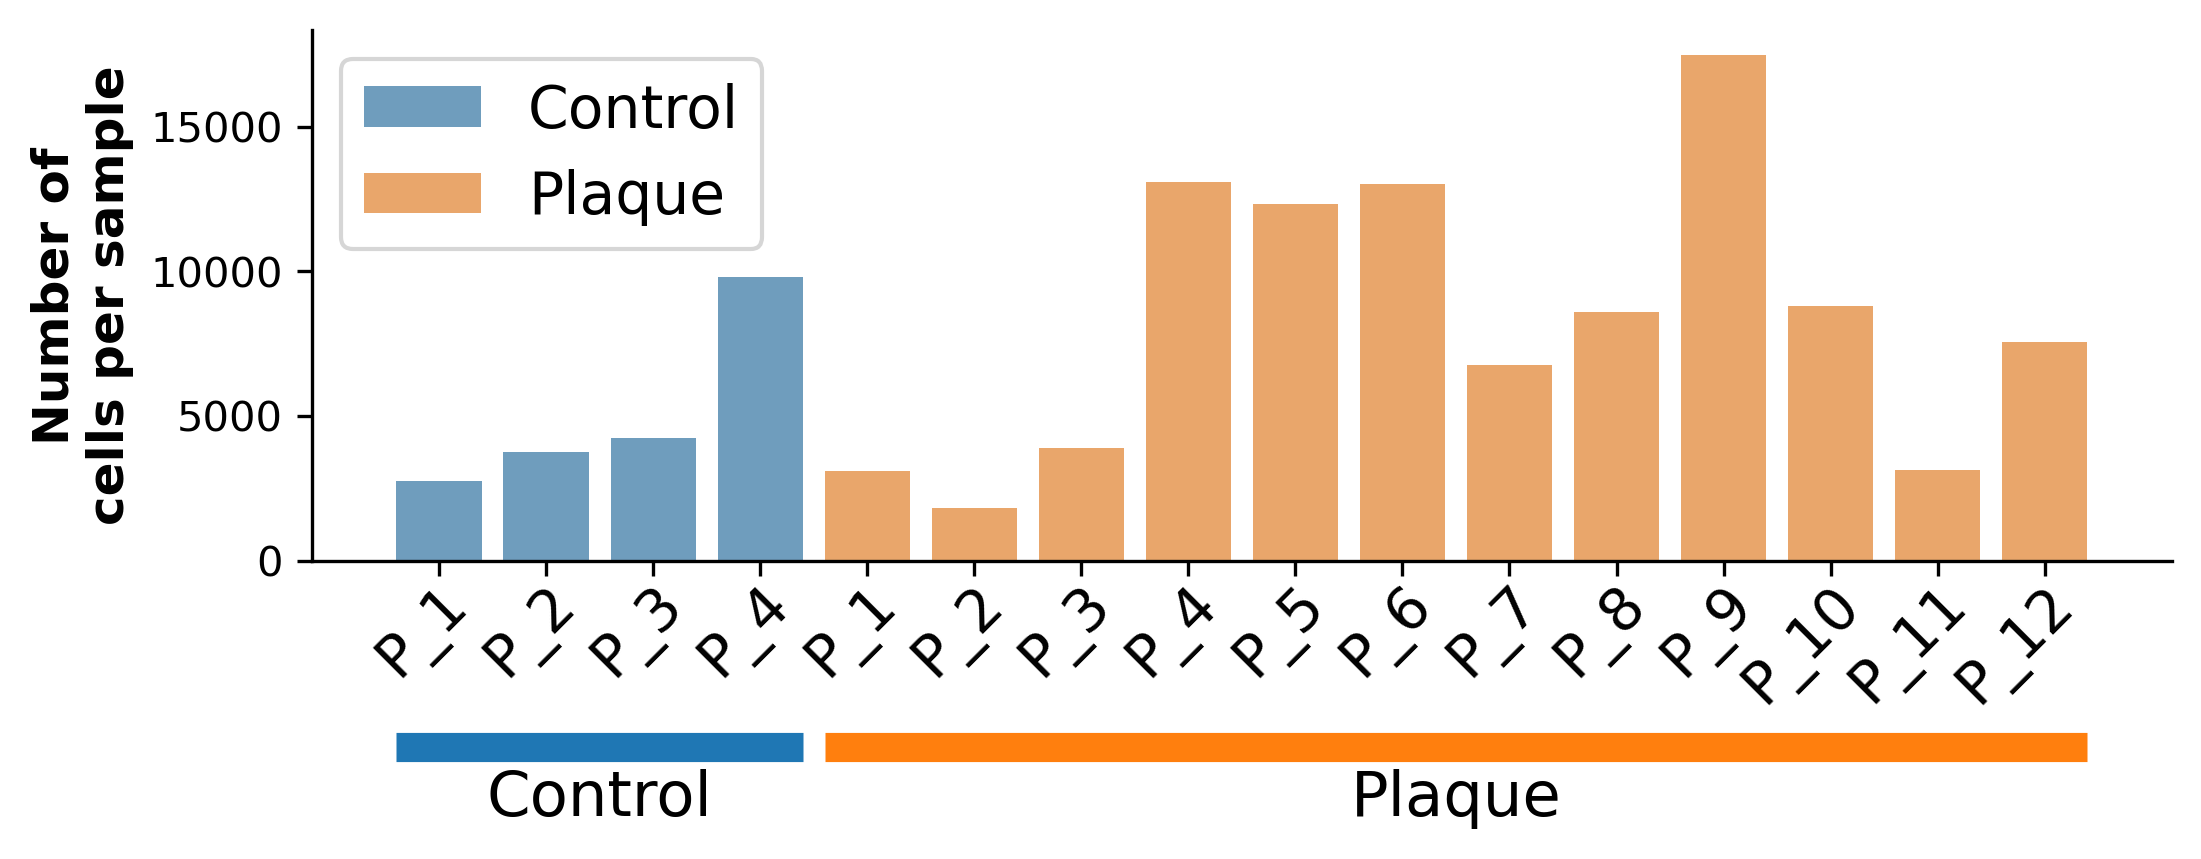

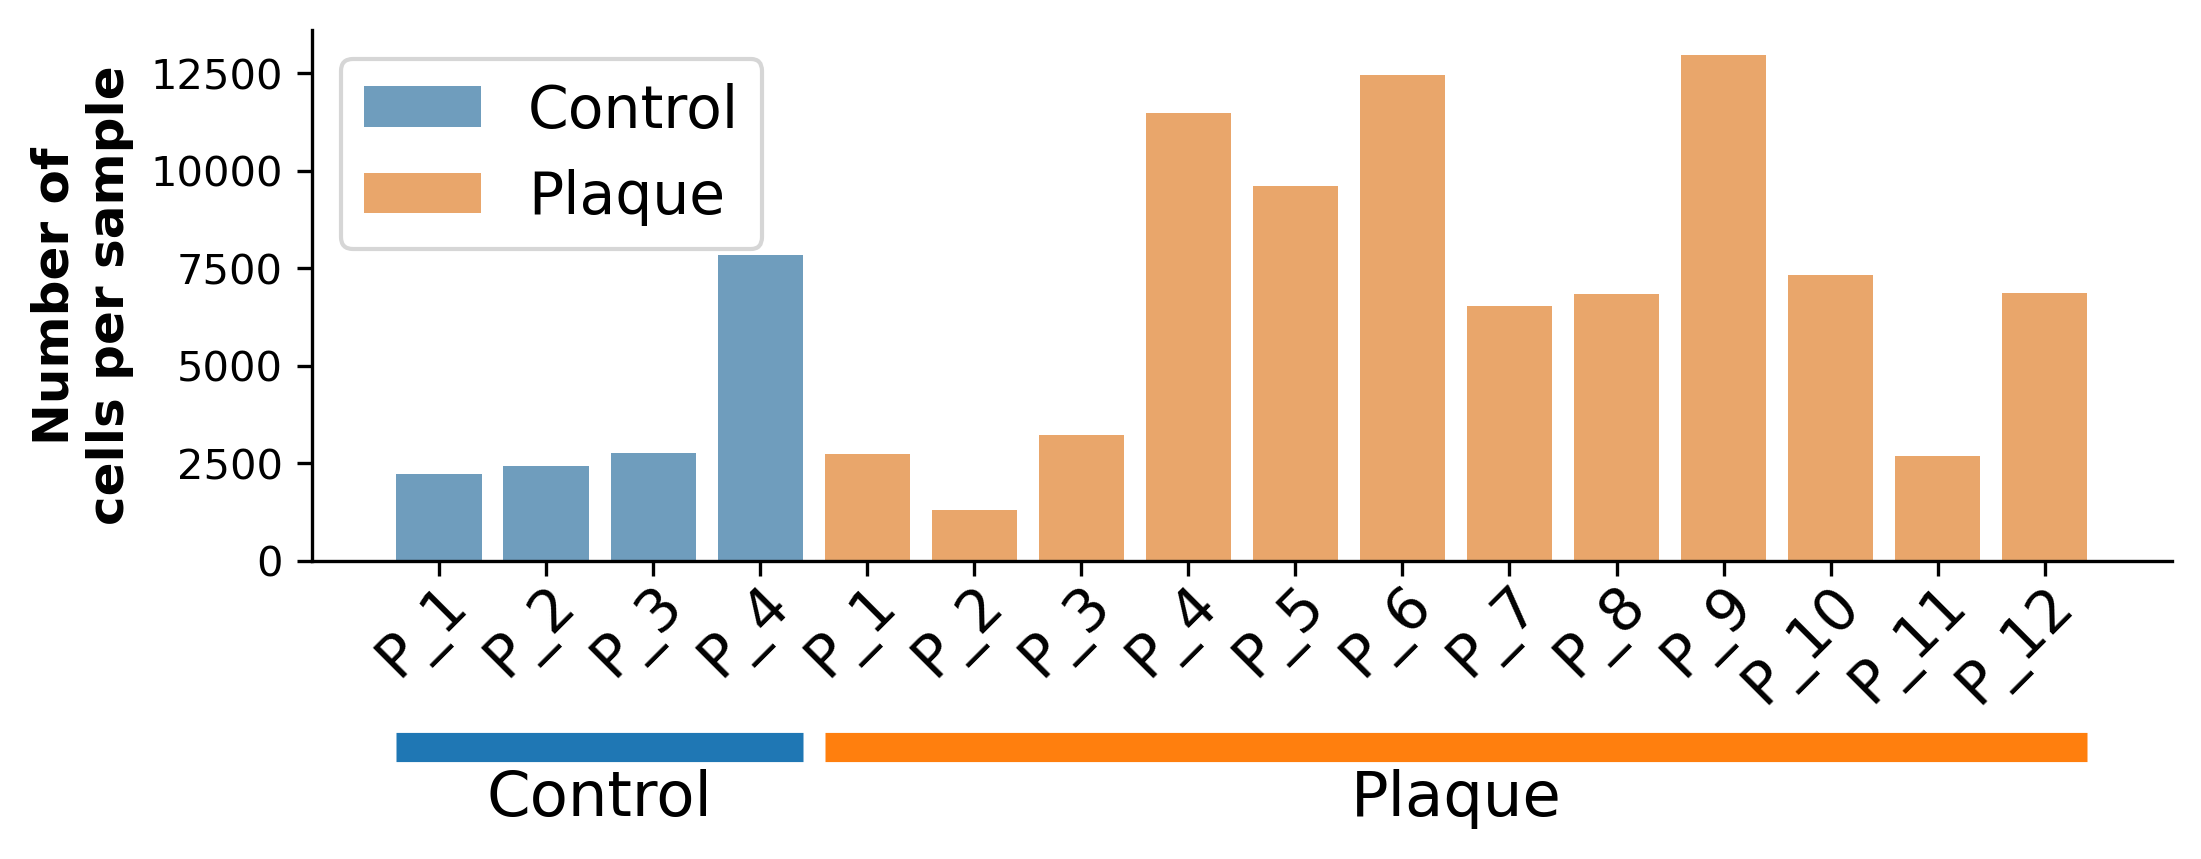

In [8]:
for panel in ['Panel1','Panel2'][:]:
    
    print(panel)
    adata=adata_dict[panel]

    adata.obs['original_sample_']=adata.obs['original_sample'].astype(str).replace({'Panel1_P':'Patient_',
                                                                                  'Panel2_P':'Patient_',
                                                                                  'Pl':'Plaque',
                                                                                   },regex=True)

    #print(adata.obs['original_sample_'].unique())
    conditions=adata.obs['condition'].unique()
    nrows=1
    ncols=len(conditions)
    #fig=plt.figure(figsize=(ncols*5,nrows*5))
    #fig,ax=plt.subplots(1,1,figsize=(ncols*4,nrows*4))
    fig,ax=plt.subplots(1,1,figsize=(ncols*4,nrows*2.3))
    print('figsize',(ncols*4,nrows*2.7))
    #fig.suptitle(f'{panel} - Number of cells per sample',y=0.98,fontweight='bold',fontsize=12)

    plot_df=adata.obs['original_sample_'].value_counts()
    plot_df=plot_df.to_frame().reset_index()
    plot_df['Condition']=adata.obs['original_sample_'].value_counts().reset_index()['original_sample_'].str.split('_',expand=True)[2].map({'Plaque':'Plaque','Ctrl':'Control'})

    plot_df=plot_df.sort_values(by=['Condition','original_sample_']).reset_index()
    plot_df['original_sample_'] = (plot_df['original_sample_'].str.split(panel+'_',expand=True)[0]).values

    plot_df['patient_id']=plot_df['original_sample_'].str.split('Patient_',expand=True)[1].str.split('_',expand=True)[0].astype(int)
    plot_df['patient_id_'] = 'P_'+plot_df['patient_id'].astype(str)

    plot_df=plot_df.sort_values(['Condition','patient_id'])
    
    sns.barplot(data=plot_df,
                x='original_sample_',
                #x='patient_id_',
                order=plot_df['original_sample_'].tolist(),
                y='count',
                hue='Condition',
                alpha=0.7,
                ax=ax)
    
    ax.set_ylabel('Number of\ncells per sample',fontsize=12,fontweight='bold')
    ax.set_xlabel(None)

    ## Add the shortes names of the patients as xticklabels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(plot_df['patient_id_'].tolist())
    plt.xticks(rotation=45,fontsize=14,ha='right',rotation_mode='anchor')
    ax.tick_params(axis='x', labelsize=14, pad=0)
    
    
    #ax.grid()
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=14)



    
    ## ADD LINES UNDER THE X AXIS THAT INDICATES THE CONDITION 
    # Add annotation bar under x-axis to show condition grouping
    # Get indices of control and plaque samples
    ctrl_idx = plot_df[plot_df['Condition'] == 'Control'].index
    plaque_idx = plot_df[plot_df['Condition'] == 'Plaque'].index
    
    # Draw lines and labels for groupings
    line_y = - 0.35
    y_offset = line_y -0.13  # vertical offset in axes coords
    linewidth=7
    condition_label_fontsize=15
    
    # Add Control group annotation
    ax.annotate('Control',
                #xy=(ctrl_idx[0], y_offset),
                xy=(ctrl_idx.to_numpy().mean(), y_offset),
                xycoords=('data', 'axes fraction'),
                fontsize=condition_label_fontsize,
                ha='center')
    ax.hlines(line_y, ctrl_idx[0] - 0.4, 
              ctrl_idx[-1] + 0.4, 
              transform=ax.get_xaxis_transform(),
              color='tab:blue', 
              linewidth=linewidth,
              clip_on=False)

    # Add Plaque group annotation
    ax.annotate('Plaque',
                #xy=(plaque_idx.mean(), y_offset),
                xy=(plaque_idx.to_numpy().mean(), y_offset),
                xycoords=('data', 'axes fraction'),
                fontsize=condition_label_fontsize,
                ha='center')
    ax.hlines(line_y, np.sort(plaque_idx)[0] - 0.4, 
              np.sort(plaque_idx)[-1] + 0.4, 
              transform=ax.get_xaxis_transform(), 
              color='tab:orange', 
              linewidth=linewidth,
              clip_on=False)

    
    ## SAvefig    
    os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','cell_number_per_sample'),exist_ok=True)
    fn=os.path.join(proc_dir,'figure_plots','Fig3','cell_number_per_sample',f'{panel}_cell_numbers_per_sample.png')
    fig.savefig(fn, dpi=300, bbox_inches='tight')



# FIG.3 - HIGH-LEVEL CELL COUNTS/PROPORTIONS

Panel1


/tmp/ipykernel_81616/2142280205.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


Panel2


/tmp/ipykernel_81616/2142280205.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


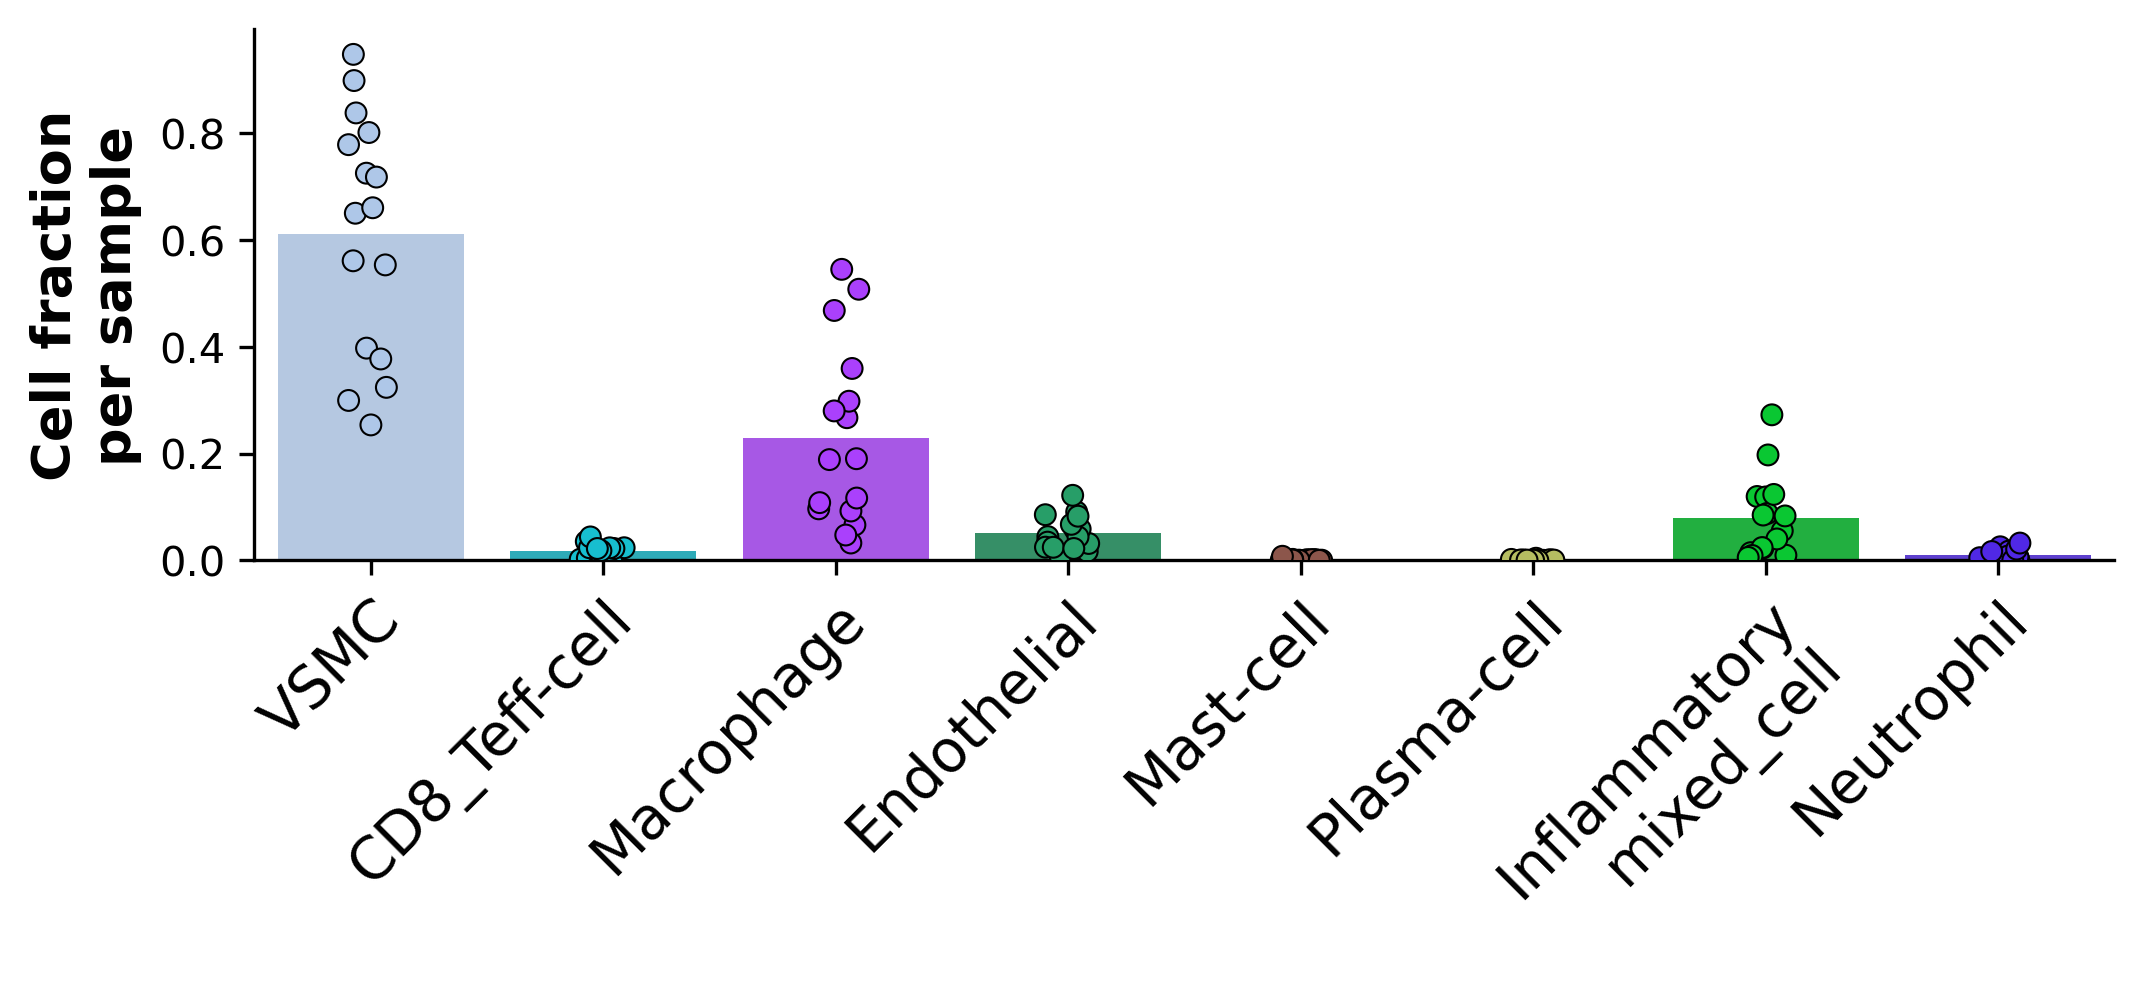

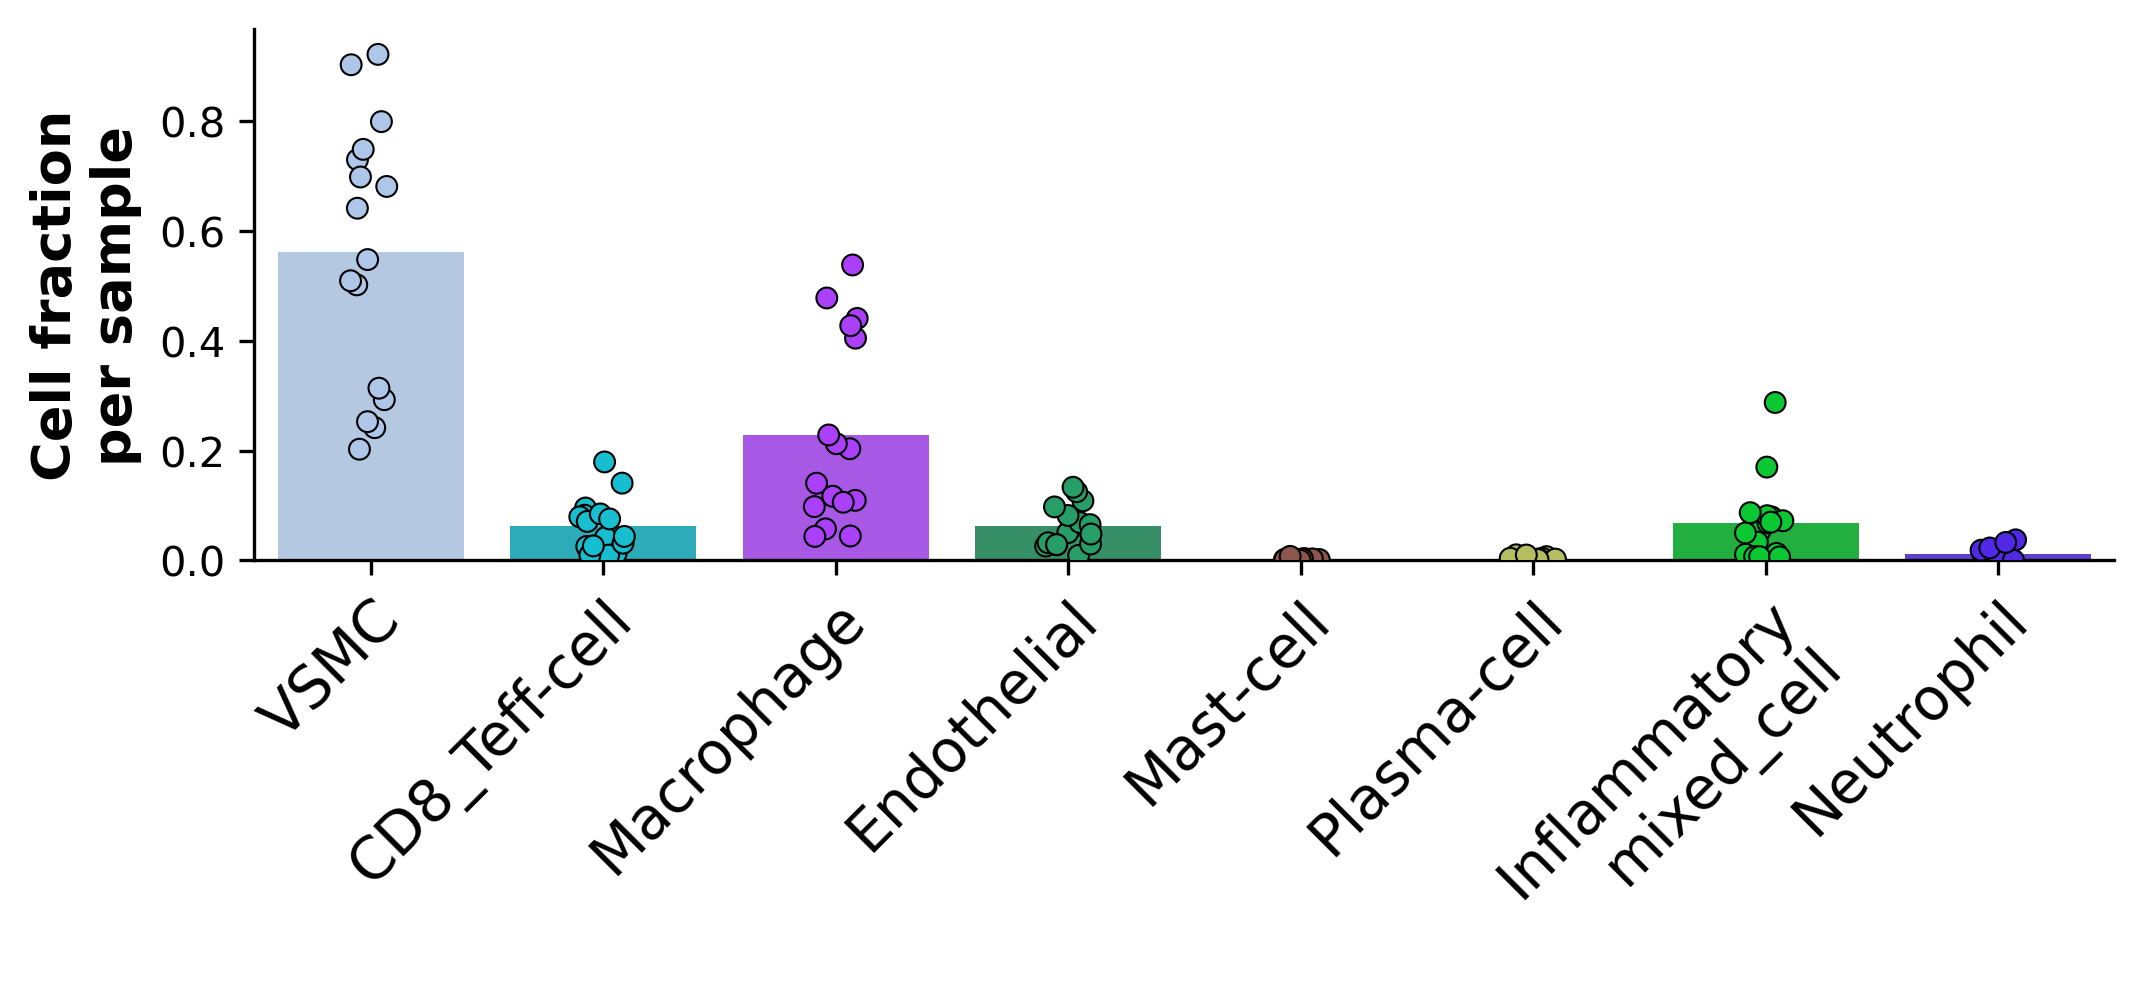

In [9]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


color_palette={'B-cell':(31,119,180,255),
               'Dendritic-cell':(255,127,14,255),
               'Endothelial':(39,158,104,255),
               'FB':(214,39,40,255),
               'Macrophage':(170,64,252,255),
               'Mast-cell':(140,86,75,255),
               'NK-cell':(227,119,194,255),
               'Plasma-cell':(181,189,97,255),
               #'T-cell':(23,190,207,255),
               'CD8_Teff-cell':(23,190,207,255),
               'VSMC':(174,199,232,255),
               'Inflammatory_mixed_cell':(10,199,50,255), 
               'Neutrophil':(80,40,230,255),
              }

color_palette= {cellt:tuple(ti/255 for ti in rgba)for cellt,rgba in color_palette.items()}


for panel in ['Panel1','Panel2'][:]:
    print(panel)
    adata=adata_dict[panel]


    for cellt_coln in  ['final_high_level_celltype','final_low_level_celltype'][:1]:
        '''
        l=[]
        for scale_param in ['5','10','15','5|10|15'][:-1]:
            adata_subs=adata_dict_[scale_param][panel]
            adata_subs.obs['Scale parameter']=scale_param
    
            abs_counts=adata_subs.obs[cellt_coln].value_counts()
            norm_counts=adata_subs.obs[cellt_coln].value_counts(normalize=True)
            count_df=pd.concat([abs_counts,norm_counts],axis=1)
            count_df['Scale parameter']=scale_param
            l.append(count_df)
        
        '''
        #hue_order=adata.obs[cellt_coln].value_counts().index.tolist()
        hue_order = [ 'VSMC', 'CD8_Teff-cell','Macrophage','Endothelial', 'Mast-cell','Plasma-cell','Inflammatory_mixed_cell','Neutrophil']
        #norm_counts=adata.obs[cellt_coln].value_counts(normalize=True)
        abs_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=False))#.reset_index()
        norm_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=True))#.reset_index()
        plot_df=pd.concat([abs_counts,norm_counts],axis=1)


    
        
        met_colnames=['count','proportion'][1:]
        met_coln_titles=['Cell count','Cell fraction\nper sample'][1:]
        #print(plot_df)
        
        
        for met_coln_title,met_coln in zip(met_coln_titles,met_colnames):

            #fig,ax=plt.subplots(1,1,figsize=(8,2.7))
            fig,ax=plt.subplots(1,1,figsize=(8,2.3))
            #fig.suptitle('scRNA-seq',fontsize=14,fontweight='bold')
    
            sns.barplot(data=plot_df.reset_index(),
                        x=cellt_coln,
                        y=met_coln,color='dodgerblue',#alpha=0.7,
                        order=hue_order,
                        errorbar=None,
                        palette=color_palette)
            
            sns.stripplot(data=plot_df,
                         x=cellt_coln,
                        y=met_coln,color='dodgerblue',#alpha=0.7,
                        order=hue_order,
                         edgecolor='black',
                          linewidth=0.5,
                        palette=color_palette)
    
            #ax.set_ylim(None,np.quantile(plot_df[met_coln],1))
            
            # Rotate x-axis tick labels by 45 degrees
            x_ticks=[label.get_text().replace('_mixed_cell','\nmixed_cell') for label in ax.get_xticklabels()]
            x_ticks=[label.replace(r'/','/\n') for label in x_ticks]
            ax.set_xticklabels(x_ticks)
            plt.xticks(rotation=45,fontsize=14,ha='right',rotation_mode='anchor')

            ax.set_ylabel(met_coln_title,fontsize=13,fontweight='bold')
            ax.set_xlabel(None)
            ax.spines[['top','right']].set_visible(False)
       
  
            ## SAvefig    
            proc_dir='../../../xenium_data/processed_data/baysor_processed_output'
            data_dir_=os.path.join(proc_dir,'figure_plots','Fig3','xenium_cell_fractions')
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                            f'{panel}_{cellt_coln}_{met_coln}_cell_fractions.png')
            fig.savefig(fn, dpi=300, bbox_inches='tight')


# CELLTYPE UMAPS

## FIG.3

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

for panel in ['Panel1','Panel2'][:]:
     
    print('\n============',panel,'============\n')
    adata=adata_dict[panel] 
    

    cell_cols=['final_high_level_celltype','final_low_level_celltype','final_low_level_celltype_substates']

    #adata.obs=adata.obs.drop(columns=['final_high_level_celltypes','final_low_level_celltypes'])
    
    for n,col in enumerate(cell_cols[:2]):
        ncols=1
        nrows=1#int(np.ceil(len(cell_cols)/ncols))
        #fig=plt.figure(figsize=(ncols*5,nrows*4.5))
        width_adj_param=7
        height_adj_param=5.5
        heigh_width_ratio=(height_adj_param/width_adj_param)

        for leg_loc in ["on data",'right margin'][1:]:
        
            fig,ax=plt.subplots(1,1,figsize=(ncols*width_adj_param,nrows*height_adj_param))
    
            #ax=fig.add_subplot(nrows,ncols,n+1) 
    
            #suptitle='-'.join([panel,param_set_string,f'\ncells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}'])
            
            suptitle=f"Xenium - {col.split('final_')[-1].replace('_',' ').capitalize()}"
            #fig.suptitle(suptitle,fontweight='bold',fontsize=10,y=0.94,x=0.5)
            #leg_loc='right margin'
    
            #if col in cell_cols:
            #    leg_loc="on data"
            
            sc.pl.umap(adata, color=col,show=False,
                       ax=ax,
                       size=3.5,
                       #vmin=0.5,
                       #vmax=1,
                       vmin='p1',
                       vmax='p99',
                       legend_fontsize=9,
                       legend_fontweight='semibold',
                       legend_loc=leg_loc)

            
            ax.set_title(None)
                        
            #plt.box(False)
            #ax.set_xlabel('UMAP1',fontsize=12, fontweight='bold',x=0.15*(height_adj_param/width_adj_param))
            #ax.set_ylabel('UMAP2',fontsize=12, fontweight='bold',y=0.15)
            ax.set_xlabel(None)
            ax.set_ylabel(None)
    
             # Adding small x and y axes in the lower-left corner
            ax.spines['bottom'].set_color('black')
            ax.spines['bottom'].set_linewidth(1)
            ax.spines['left'].set_color('black')
            ax.spines['left'].set_linewidth(1)
            
            # Hide top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
    
            # Set custom limits for small axes
            # Set custom bounds for equally long axes
            x_axis_length = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.2  # Define axis length
            x_axis_offset=x_axis_length*0.1
            y_axis_length = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.2 * (1/heigh_width_ratio)  # Define axis length
            y_axis_offset=y_axis_length*0.1
            
            x_start, x_end = ax.get_xlim()[0]+x_axis_offset, ax.get_xlim()[0] + x_axis_length
            y_start, y_end = ax.get_ylim()[0]+y_axis_offset, ax.get_ylim()[0] + y_axis_length
            
            ax.spines['bottom'].set_bounds(x_start, x_end)
            ax.spines['left'].set_bounds(y_start, y_end)
            
            # Add arrows to axis tips        
            arrow_style = mpatches.ArrowStyle("-|>", head_length=0.5, head_width=0.2)
            ax.annotate('', xy=(x_end+0.5, ax.get_ylim()[0]), xytext=(x_end - 0.001 * x_axis_length, ax.get_ylim()[0]), 
                        arrowprops=dict(arrowstyle=arrow_style, color='black', lw=1))
            ax.annotate('', xy=(ax.get_xlim()[0], y_end+0.5), xytext=(ax.get_xlim()[0], y_end - 0.001 * y_axis_length), 
                        arrowprops=dict(arrowstyle=arrow_style, color='black', lw=1))
    
    
            ## Add label titles
            ax_label_offset=0.4
            ax.text((x_start+x_end)/2, ax.get_ylim()[0]-ax_label_offset,'UMAP1',weight='bold',fontsize=12,
                    horizontalalignment='center',verticalalignment='center')
            ax.text(ax.get_xlim()[0]-ax_label_offset, (y_start+y_end)/2, 'UMAP2',weight='bold',fontsize=12, 
                    horizontalalignment='center',rotation_mode='anchor',rotation=90,
                    verticalalignment='center')



            # If there is a legend, remove it and add a customized one
            if leg_loc=='right margin':
                
                ax.legend_.remove()

                
                legend_handles=[Line2D([0],[0],marker="o",color=c,lw=0,label=l,markerfacecolor=c,markersize=7,)
                                    for l, c in zip(list(adata.obs[col].cat.categories), adata.uns[f"{col}_colors"])]
                '''                
                # Make new Legend
                l1 = ax.legend(handles=legend_handles,                
                               frameon=False,
                               ncols=1,
                               loc='upper left',
                               bbox_to_anchor=(1, 0.75),
                               #title="Cell type",
                              )
                '''                              
            
    
            ## SAvefig    
            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','UMAP'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig3','UMAP',f'{panel}_{col}_legend_{leg_loc}_UMAP.png')
            fig.savefig(fn, dpi=300, bbox_inches='tight')
            
            ##### SAVE LEGEND FOR CELL TYPE AND REGIONS AS SEPARATE FIGURES
            if leg_loc=='right margin':
                # Create a new figure for the legend
                legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed
                legend_ax.axis('off')  # Turn off the axis for a clean legend

                ncols = 3 if len(legend_handles)>20 else 1
                l1 = legend_ax.legend(handles=legend_handles,                
                                       frameon=False,
                                       ncols=ncols,
                                       markerscale=2,
                                       fontsize=25,
                                       loc='center',
                                       #bbox_to_anchor=(1, 0.75),
                                       #title="Cell type",
                                            )

                os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','UMAP'),exist_ok=True)
                fn=os.path.join(proc_dir,'figure_plots','Fig3','UMAP',f'{panel}_{col}_legend_{leg_loc}_UMAP_legend.png')
                legend_fig.savefig(fn, dpi=300, bbox_inches='tight')
         

## FIG.3 - Interactive UMAP

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import os

# Assume adata.obs contains UMAP coordinates and cell type annotations
for panel in ['Panel1', 'Panel2'][:]:
    print('\n============', panel, '============\n')
    adata = adata_dict[panel]

    cell_cols = ['final_high_level_celltype', 'final_low_level_celltype', 'final_low_level_celltype_substates']
    
    for col in cell_cols[-1:]:
        # Prepare UMAP data
        umap_df = pd.DataFrame({
            'UMAP1': adata.obsm['X_umap'][:, 0],  # UMAP x-coordinates
            'UMAP2': adata.obsm['X_umap'][:, 1],  # UMAP y-coordinates
            'CellType': adata.obs[col].values,  # Cell type annotations
        })

        # Get unique cell types
        unique_cell_types = sorted(umap_df['CellType'].unique())

        # Create figure
        fig = go.Figure()

        # Add a "background" layer (grey dots for all points) using scattergl (FAST)
        fig.add_trace(go.Scattergl(
            x=umap_df['UMAP1'],
            y=umap_df['UMAP2'],
            mode='markers',
            marker=dict(size=4, opacity=0.2, color='lightgrey'),  # Light grey background dots
            name="All Cells (background)",
            showlegend=False  # Hide in legend
        ))

        # Add separate traces for each cell type using scattergl (FAST)
        for cell_type in unique_cell_types:
            subset = umap_df[umap_df['CellType'] == cell_type]
            
            fig.add_trace(go.Scattergl(
                x=subset['UMAP1'],
                y=subset['UMAP2'],
                mode='markers',
                marker=dict(size=5, opacity=1),  # Visible by default
                name=cell_type,  # Legend item
                hovertemplate=f"Cell Type: {cell_type}<br>UMAP1: {{x}}<br>UMAP2: {{y}}<extra></extra>",
            ))

        # **Optimize Legend Interactivity**
        legend_title=col.split('final_')[-1].replace('_',' ').capitalize()
        
        fig.update_layout(
            title=dict(
                text=panel,  # Suptitle text
                x=0.4,  # Center the title
                xanchor='center',  # Ensure anchor is centered
                y=0.95,  # Position title near top
                font=dict(size=30, family="Arial, sans-serif", color="black", weight="bold")  # Font size, weight
            ),
            legend=dict(
                title=dict(  # **Customize Legend Title**
                    text=legend_title,
                    font=dict(size=16, family="Arial, sans-serif", color="black",weight="bold")  # Set font size & color
                ),
                font=dict(size=14, family="Arial, sans-serif", color="black"),  # **Customize Legend Items**
                itemsizing="constant",
                traceorder="normal",  # Ensures legend stays sorted as added
                itemclick="toggleothers",  # Click to highlight one cell type
                itemdoubleclick="toggle"  # Double-click to isolate one cell type
            ),
            width=1400,
            height=900
        )


        # Show the plot
        fig.show()

        # Save as an interactive HTML file
        output_file_path = os.path.join(proc_dir, 'figure_plots', 'Fig3', 'UMAP', f"{panel}_{col}_fast_interactive_umap.html")
        pio.write_html(fig, file=output_file_path, auto_open=False)


# CLUSTER SAMPLES BASED ON SAMPLE REGION/CELLTYPE FRACTIONS

## Cell type fractions

### FIG.5

In [ ]:


sample_inclusion_dict={'all_samples':'',
                      'diseased_only':'_Pl',
                      'healthy_only':'_Ctrl'}

color_var='final_low_level_celltype'
color_var='final_high_level_celltype'
color_var='final_low_level_celltype_substates'

for panel in ['Panel1','Panel2'][:]:
    
    print(panel)
    adata=adata_dict[panel]

    adata.obs['BMI']=adata.obs['BMI'].astype(float)

    for sample_incl in [*sample_inclusion_dict][1:2]:

        
        adata_=adata[adata.obs['original_sample'].str.contains(sample_inclusion_dict[sample_incl]),:].copy()

        adata_.obs['original_sample_']=adata_.obs['original_sample'].astype(str).replace({'Panel1_P':'Patient_',
                                                                                  'Panel2_P':'Patient_',
                                                                                  'Pl':'Plaque',
                                                                                   },regex=True)
        orig_samples=adata_.obs.loc[:,'original_sample_'].unique()
   
        ## Set ncol/nrows for figure size
        nrows=max(len(orig_samples),12)
        ncols=len(adata.obs[color_var].unique())
    
    
        ## Define varible used for coloring
        l=[]
        for n,orig_sample in enumerate(orig_samples[:]):
            #print(orig_sample)
            #ax=fig.add_subplot(nrows,ncols,n+1)
            
            adata_sample=adata_[adata_.obs['original_sample_']==orig_sample,:].copy()
    
            celltype_freqs=adata_sample.obs[color_var].value_counts(normalize=True,dropna=False) * 100
            #celltype_freqs=adata_sample.obs[color_var].value_counts(normalize=False,dropna=False)
            
            #if 'T-cell_0' in celltype_freqs.index:
            #    celltype_freqs=celltype_freqs.drop(['T-cell_0'],axis=0)
            l.append(celltype_freqs)
    
            
        #sns.set_style("whitegrid", {'axes.grid' : False})
        
        ## Concatenate the frequencias of the individual samples + fill Na with 0
        cellt_freq_df=pd.concat(l,axis=1)
        cellt_freq_df.columns=orig_samples
        cellt_freq_df=cellt_freq_df.fillna(0)
    
        leg_up_y_lim=2.5
        leg_fontsize=4
        leg_title_fontsize=4.5
        y_dist_ratio=0.85

        column_colours_params={'condition':{'color_palette':'tab10',
                                          'legend_title':'Condition',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-0.98+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'stability':{'color_palette':'Set2',
                                          'legend_title':'Stability',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-1.42*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'symptomatic':{'color_palette':'rocket',
                                          'legend_title':'Symptomatic',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-1.9*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Diabetes':{'color_palette':'tab10',
                                          'legend_title':'Diabetes',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-2.35*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Dyslipidemia':{'color_palette':'Set2',
                                          'legend_title':'Dyslipidemia',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-2.8*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Hypertension':{'color_palette':'rocket',
                                          'legend_title':'Hypertension',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-3.25*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Smoking_ever':{'color_palette':'tab10',
                                          'legend_title':'Smoking_ever',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-3.7*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Sex':{'color_palette':'Set2',
                                          'legend_title':'Sex',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                               
                            'Age':{'color_palette':'viridis',
                                          'legend_title':'Age',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
        
                            'BMI':{'color_palette':'rocket',
                                          'legend_title':'BMI',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                            
                             'Height':{'color_palette':'plasma',
                                          'legend_title':'Height',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize}}
        
        ## Create column colouring for the clustermap via custom function
        #col_color_dict = create_column_colors(orig_samples,cellt_freq_df,column_colours_params)
        col_color_dict = create_column_colors(adata_.obs,cellt_freq_df,column_colours_params)
        #col_color_dict=create_unique_column_colors(orig_samples, cellt_freq_df, column_colours_params,'tab20')
        #col_colors_list=[col_color_dict[column_col_var]['column_colors'] for column_col_var in col_color_dict.keys()]
        col_colors_list = [col_color_dict[column_col_var]['column_colors'] for column_col_var in column_colours_params.keys()]

        cbar_pos=(-0.03, 0.25, 0.03, 0.5)
        cbar_pos=(0.3, 1, 0.4, 0.02)

        cellt_freq_df.columns = cellt_freq_df.columns.str.replace('Patient','P')
        
        if panel=='Panel1':
            
            figsize=(10,10)
            figsize=(12,7.5)
            annot_fs=str(5.2)
            plot_df=cellt_freq_df.T
            row_colors=col_colors_list
            col_colors=None
            cbar_pos=(0.3, 1, 0.4, 0.02)
            xticklabels=True
            yticklabels=False
        
        if panel=='Panel2':
            figsize=(10,12)
            #figsize=(13,7.5)
            annot_fs=str(5.2)
            plot_df=cellt_freq_df.copy()
            col_colors=col_colors_list
            row_colors=None
            cbar_pos=(-0.03, 0.25, 0.03, 0.5)
            xticklabels=False
            yticklabels=True

        

        
        
        g=sns.clustermap(plot_df,
                         row_cluster=True, 
                         col_cluster=True, 
                         method='ward', 
                         metric='euclidean', 
                         col_colors=col_colors,
                         row_colors=row_colors,
                         #colors_ratio=0.018,
                         colors_ratio=0.015,
                         xticklabels=xticklabels,
                         yticklabels=yticklabels,
                         tree_kws=dict(linewidths=1.5),
                         dendrogram_ratio=(0.06,0.08),
                         #cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                         #cbar_pos=(0.3, 1, 0.4, 0.02),
                         cbar_pos=cbar_pos,
                         #cbar_kws={'label':'Cell fraction within sample %'},
                         #z_score=1,
                         annot=True,
                         fmt='.1f',
                         annot_kws={'fontsize':annot_fs},
                         #vmax=np.percentile(cellt_freq_df.apply(zscore).values.flatten(),99),
                         vmax=np.percentile(plot_df.values.flatten(),99.5),
                         cmap='viridis',
                         linewidths=0.000,
                         linecolor='yellow',
                         figsize=figsize)
                         #figsize=(0.75*nrows,0.6*ncols))
                         #figsize=(0.6*nrows,0.3*ncols),)
                         #colors_ratio=0.005)

                         

        if panel=='Panel2':
            # Adjust the position of the colorbar label
            g.ax_cbar.yaxis.set_label_position("left")
            g.ax_cbar.yaxis.tick_left()
            #g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=14, fontweight='bold')
            g.ax_cbar.set_ylabel('Cell fraction within sample %', fontsize=13, fontweight='bold')
            g.ax_cbar.tick_params(labelsize=10, width=1.5)

        if panel=='Panel1':
            # Remove default colorbar and redraw it horizontally
            cbar = g.fig.colorbar(
                g.ax_heatmap.collections[0],  # The heatmap image
                cax=g.ax_cbar,  # Use the same cbar axis
                orientation='horizontal'
            )
            
            # Format horizontal colorbar
            cbar.ax.xaxis.set_label_position("top")
            cbar.ax.xaxis.set_ticks_position("top")
            cbar.set_label('Cell fraction within sample %', fontsize=13, fontweight='bold')
            cbar.ax.tick_params(labelsize=10, width=1.5)
        
        #g.fig.suptitle(f'{panel} - Sample region fractions',y=1.05,fontsize=12,fontweight='bold')
        g.ax_heatmap.set_ylabel(None)
        g.ax_heatmap.set_xlabel(None)

        #g.ax_heatmap.set_yticklabels(cellt_freq_df.index, fontsize=12, rotation=0, va="center")  # Set labels
        if color_var=='final_low_level_celltype_substates':
            ytick_fontsize=8
        
        if color_var=='final_low_level_celltype':
            ytick_fontsize=12
            
        g.ax_heatmap.tick_params(axis='y',labelsize=10.5,labelbottom=True)
        g.ax_heatmap.tick_params(axis='x',labelsize=ytick_fontsize,labelbottom=True)
         
        
        ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
        # Calculate the y positions for the ticks
        num_col_colors = len(col_color_dict)
        yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
        
        if panel=='Panel2':
            g.ax_col_colors.set_yticks(yticks)
            
            # Set the tick labels on the right side
            g.ax_col_colors.yaxis.tick_right()
            #g.ax_row_colors.yaxis.tick_right()
        
        if panel=='Panel1':
            g.ax_row_colors.set_xticks(yticks)
        
       
        
        # Set the tick labels for each color bar
        col_col_names=[column_colours_params[key]['legend_title'] for key in column_colours_params.keys()]

        if panel=='Panel2':
            g.ax_col_colors.set_yticklabels(col_col_names, 
                                            fontsize=9,  # Adjust fontsize here
                                            ha='left',  # Horizontal alignment to be closer to the color bars
                                            weight='bold'
                                           )
        if panel=='Panel1':
            g.ax_row_colors.set_xticklabels(col_col_names, 
                                            fontsize=9,  # Adjust fontsize here
                                            ha='center',  # Horizontal alignment to be closer to the color bars
                                            rotation=90,
                                            weight='bold'
                                           )
        

        ## SAvefig    
        os.makedirs(os.path.join(proc_dir,'figure_plots','Fig5','celltype_fractions'),exist_ok=True)
        fn=os.path.join(proc_dir,'figure_plots','Fig5','celltype_fractions',f'{panel}_{sample_incl}_clustered_by_{color_var}_celltype_fractions.png')
        #g.fig.savefig(fn, bbox_inches='tight', dpi=300)

        
        
        ## CREATE LEGEND FOR COLUMN COLOURING AND SAVE THEM AS SEPARATE FIGURE (Multiple LAYOUTS: 1/2 COLUMNS OF LEGENDS/ ALL LEGENDS IN 1 ROW)
        #create_column_col_legend(g,column_colours_params)
        #create_column_col_legend(g,col_color_dict)
            
        comp_ncols=2
        #comp_ncols=len(col_color_dict.keys())

        for comp_ncols in [1,2,len(col_color_dict.keys())]:
            y_offset=1
            x_offset=0
            y_shift=0.03
            x_shift=0.12
            leg_fontsize=12
            leg_title_fontsize=13
            markerscale=1.5
            #create_composite_column_col_legend(g, col_color_dict, column_colours_params,
            #                                  comp_ncols,y_offset,x_offset,y_shift,x_shift)
    
            ### EXTRACT CATEGORICAL LEGENDS
            legend_save_path = os.path.join(proc_dir, 'xenium_plots', 'celltype_clustermaps', 'composite_legend.png')
            leg_figsize=(comp_ncols*5,(len(col_color_dict.keys())/comp_ncols)*5)
            leg_figsize=(12,12)

            ## Subset col_colo_dict to the categorical variables
            col_color_dict_cat = {key: col_color_dict[key] for key in col_color_dict.keys() if key not in ['Age','Weight','Height','BMI']}
            
            legend_fig = extract_composite_legend(leg_figsize,col_color_dict_cat, column_colours_params, 
                                                  comp_ncols, y_offset, x_offset, y_shift, x_shift, 
                                                  legend_save_path,leg_fontsize,leg_title_fontsize,markerscale)

            plt.tight_layout()
            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig5','celltype_fractions'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig5','celltype_fractions',f'{panel}_{sample_incl}_clustered_by_{color_var}_celltype_fractions_categorical_legend_ncols_{comp_ncols}.png')
            legend_fig.savefig(fn, bbox_inches='tight', dpi=300)

            
            ### EXTRACT COLORBAR OF NUMERICAL VARIABLES
            if comp_ncols in [1,len(col_color_dict.keys())]:
                cbar_x_shift_vertical=0.1
                cbar_x_shift_horizontal=0.01
                
                ## Subset col_colo_dict to the categorical variables
                col_color_dict_num = {key: col_color_dict[key] for key in col_color_dict.keys() if key in ['Age','Weight','Height','BMI']}
                
                legend_fig_cb=extract_composite_colorbar(leg_figsize,col_color_dict_num, column_colours_params, 
                                                          comp_ncols, y_offset, x_offset, y_shift, x_shift, 
                                                          leg_fontsize,leg_title_fontsize,markerscale,
                                                         cbar_x_shift_vertical,cbar_x_shift_horizontal)
                plt.tight_layout()
                os.makedirs(os.path.join(proc_dir,'figure_plots','Fig5','celltype_fractions'),exist_ok=True)
                fn=os.path.join(proc_dir,'figure_plots','Fig5','celltype_fractions',f'{panel}_{sample_incl}_clustered_by_{color_var}_celltype_fractions_colorbars_ncols_{comp_ncols}.png')
                legend_fig_cb.savefig(fn, bbox_inches='tight', dpi=300)

        
        ## EXTRACT PATIENT CLUSTERS FROM DENDROGRAM
        ## Extractr column dendrogram clusters ==> exract patient clusters based on the clustermap created by embedding cluster fractions
        if sample_incl=='diseased_only' and panel=='Panel1':
            
            import scipy.cluster.hierarchy as sch
            # retrieve clusters using fcluster 
            d = sch.distance.pdist(cellt_freq_df.T,metric='euclidean')
            L = sch.linkage(d, method='ward')
            
            ## 0.2 can be modified to retrieve more stringent or relaxed clusters
            #clusters = sch.fcluster(L, 0.8*d.max(), 'distance')
    
            n_clusters = 4
            clusters = sch.fcluster(L, n_clusters, criterion='maxclust')
            
            pat_clust_dict = dict(zip(cellt_freq_df.columns,clusters))
            
            adata_.obs[f'{color_var}_pat_clust']=adata_.obs['original_sample'].map(pat_clust_dict)
    
            ## Add to original adata with all patients
            adata.obs[f'{color_var}_pat_clust']=np.nan
            adata.obs.loc[adata_.obs.index,f'{color_var}_pat_clust']=adata_.obs[f'{color_var}_pat_clust'].values
        
    adata_dict[panel]=adata
                
            

## Sample region fractions for each sample

### FIG.3 plot

In [ ]:
sample_inclusion_dict={'all_samples':'',
                      'diseased_only':'_Pl',
                      'healthy_only':'_Ctrl'}



for panel in ['Panel1','Panel2'][:1]:
    print(panel)
    adata=adata_dict[panel]

    adata.obs['BMI']=adata.obs['BMI'].astype(float)

    #adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
    #orig_samples=adata.obs.loc[:,'original_sample'].unique()
    orig_samples=adata.obs.loc[~adata.obs['sample_region'].isna(),'original_sample'].unique()
    ncols=2
    nrows=int(np.ceil(len(orig_samples)/ncols))


    ## Define varible used for coloring
    color_var='deseq2_high_level_celltype' 
    color_var='deseq2_low_level_cluster_'
    #color_var='manual_low_level_cluster_'
    color_var='sample_region'

    for sample_incl in [*sample_inclusion_dict][:1]:
        
        adata_=adata[adata.obs['original_sample'].str.contains(sample_inclusion_dict[sample_incl]),:].copy()

        adata_.obs['original_sample_']=adata_.obs['original_sample'].astype(str).replace({'Panel1_P':'Patient_',
                                                                                          'Panel2_P':'Patient_',
                                                                                          'Pl':'Plaque',
                                                                                           },regex=True)
        orig_samples=adata_.obs.loc[:,'original_sample_'].unique()
   
        ## Set ncol/nrows for figure size
        nrows=max(len(orig_samples),12)
        ncols=len(adata.obs[color_var].unique())
         
        l=[]
        for n,orig_sample in enumerate(orig_samples[:]):
            #print(orig_sample)
            #ax=fig.add_subplot(nrows,ncols,n+1)
            
            adata_sample=adata_[adata_.obs['original_sample_']==orig_sample,:].copy()
    
            celltype_freqs=adata_sample.obs[color_var].value_counts(normalize=True,dropna=False) * 100
            #celltype_freqs=adata_sample.obs.groupby('sample_region').apply(lambda x: x[color_var].value_counts(normalize=True,dropna=False))
            
            #if 'T-cell_0' in celltype_freqs.index:
            #    celltype_freqs=celltype_freqs.drop(['T-cell_0'],axis=0)
            l.append(celltype_freqs)
    
            
        sns.set_style("whitegrid", {'axes.grid' : False})
        
        ## Concatenate the frequencias of the individual samples + fill Na with 0
        cellt_freq_df=pd.concat(l,axis=1)
        cellt_freq_df.columns=orig_samples
        cellt_freq_df=cellt_freq_df.fillna(0)
        cellt_freq_df=cellt_freq_df.loc[~cellt_freq_df.index.get_level_values('sample_region').isin(['Lumen','Thrombus'][:]),:]
    
    
    
        leg_up_y_lim=2.5
        leg_fontsize=4
        leg_title_fontsize=4.5
        y_dist_ratio=0.85
    
        column_colours_params={'condition':{'color_palette':'tab10',
                                          'legend_title':'Condition',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-0.98+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'stability':{'color_palette':'Set2',
                                          'legend_title':'Stability',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-1.42*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'symptomatic':{'color_palette':'rocket',
                                          'legend_title':'Symptomatic',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-1.9*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Diabetes':{'color_palette':'tab10',
                                          'legend_title':'Diabetes',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-2.35*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Dyslipidemia':{'color_palette':'Set2',
                                          'legend_title':'Dyslipidemia',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-2.8*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Hypertension':{'color_palette':'rocket',
                                          'legend_title':'Hypertension',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-3.25*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Smoking_ever':{'color_palette':'tab10',
                                          'legend_title':'Smoking_ever',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-3.7*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Sex':{'color_palette':'Set2',
                                          'legend_title':'Sex',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                               
                            'Age':{'color_palette':'viridis',
                                          'legend_title':'Age',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
        
                            'BMI':{'color_palette':'rocket',
                                          'legend_title':'BMI',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                            
                             'Height':{'color_palette':'plasma',
                                          'legend_title':'Height',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize}}
        
        ## Create column colouring for the clustermap via custom function
        col_color_dict = create_column_colors(adata_.obs,cellt_freq_df,column_colours_params)
        #col_color_dict=create_unique_column_colors(orig_samples, cellt_freq_df, column_colours_params,'tab20')
        #col_colors_list=[col_color_dict[column_col_var]['column_colors'] for column_col_var in col_color_dict.keys()]
        col_colors_list = [col_color_dict[column_col_var]['column_colors'] for column_col_var in column_colours_params.keys()]
    
        figsize=(10,6)
        figsize=(11,13)
        cellt_freq_df.columns = cellt_freq_df.columns.str.replace('Patient','P')
        
        g=sns.clustermap(cellt_freq_df, 
                         row_cluster=True,
                         col_cluster=True, 
                         method='ward', 
                         metric='euclidean', 
                         col_colors=col_colors_list, 
                         dendrogram_ratio=(0.06,0.14),
                         tree_kws=dict(linewidths=1.5),
                         #dendrogram_ratio=(0.06,0.05),
                         #cbar_pos='left',
                         cbar_pos=None,
                         colors_ratio=0.03,
                         #cbar_pos=(-0.02, 0.3, 0.02, 0.5),
                         #cbar_kws={'label':'Cell fraction within sample %'},
                         annot=True,
                         fmt='.1f',
                         annot_kws={'fontsize':'17'},
                         #vmax=np.percentile(cellt_freq_df.apply(zscore).values.flatten(),99),
                         vmax=np.percentile(cellt_freq_df.values.flatten(),99.5),
                         z_score=None,
                         cmap='viridis', 
                         linewidths=0.00,
                         figsize=figsize)
                         #figsize=(0.61*nrows,0.86*ncols))


        #g.fig.suptitle('Cell fraction within sample (%)',y=1.06,fontsize=18)
    
        # Adjust the position of the colorbar label
        #g.ax_cbar.yaxis.set_label_position("left")
        #g.ax_cbar.yaxis.tick_left()
        #g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=14, fontweight='bold')
        #g.ax_cbar.tick_params(labelsize=14, width=1.5)
        
        #g.fig.suptitle(f'{panel} - Sample region fractions',y=1.05,fontsize=12,fontweight='bold')
        g.ax_heatmap.set_ylabel(None)

        g.ax_heatmap.set_yticklabels([a.get_text() for a in g.ax_heatmap.get_yticklabels()], fontsize=12, rotation=0, va="center")  # Set labels
        g.ax_heatmap.tick_params(axis='x',labelsize=23,labelbottom=True,rotation=90)
        g.ax_heatmap.tick_params(axis='y',labelsize=23,labelbottom=True)

        #for label in g.ax_heatmap.get_xticklabels():
        #    label.set_horizontalalignment('right')      # or 'left', 'center'
        #    label.set_rotation_mode('anchor')   

        
        ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
        # Calculate the y positions for the ticks
        num_col_colors = len(col_color_dict)
        yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
        g.ax_col_colors.set_yticks(yticks)
        
        # Set the tick labels on the right side
        g.ax_col_colors.yaxis.tick_right()
        
        # Set the tick labels for each color bar
        col_col_names=[column_colours_params[key]['legend_title'] for key in column_colours_params.keys()]
        g.ax_col_colors.set_yticklabels(col_col_names, 
                                        fontsize=20,  # Adjust fontsize here
                                        ha='left',  # Horizontal alignment to be closer to the color bars
                                        #weight='bold'
                                       )
    

        ## SAvefig    
        os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','celltype_fractions_per_region'),exist_ok=True)
        fn=os.path.join(proc_dir,'figure_plots','Fig3','celltype_fractions_per_region',f'{panel}_{sample_incl}_clustered_by_{color_var}_celltype_fractions_per_region.png')
        g.fig.savefig(fn, bbox_inches='tight', dpi=300)


        
        ## CREATE LEGEND FOR COLUMN COLOURING AND SAVE THEM AS SEPARATE FIGURE (Multiple LAYOUTS: 1/2 COLUMNS OF LEGENDS/ ALL LEGENDS IN 1 ROW)
        #create_column_col_legend(g,column_colours_params)
        #create_column_col_legend(g,col_color_dict)
            
        comp_ncols=2
        #comp_ncols=len(col_color_dict.keys())

        for comp_ncols in [1,2,len(col_color_dict.keys())]:
            y_offset=1
            x_offset=0
            y_shift=0.03
            x_shift=0.12
            leg_fontsize=12
            leg_title_fontsize=13
            markerscale=1.5
            #create_composite_column_col_legend(g, col_color_dict, column_colours_params,
            #                                  comp_ncols,y_offset,x_offset,y_shift,x_shift)
    
            ### EXTRACT CATEGORICAL LEGENDS
            legend_save_path = os.path.join(proc_dir, 'xenium_plots', 'celltype_clustermaps', 'composite_legend.png')
            leg_figsize=(comp_ncols*5,(len(col_color_dict.keys())/comp_ncols)*5)
            leg_figsize=(12,12)

            ## Subset col_colo_dict to the categorical variables
            col_color_dict_cat = {key: col_color_dict[key] for key in col_color_dict.keys() if key not in ['Age','Weight','Height','BMI']}
            
            legend_fig = extract_composite_legend(leg_figsize,col_color_dict_cat, column_colours_params, 
                                                  comp_ncols, y_offset, x_offset, y_shift, x_shift, 
                                                  legend_save_path,leg_fontsize,leg_title_fontsize,markerscale)

            plt.tight_layout()
            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','celltype_fractions_per_region'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig3','celltype_fractions_per_region',f'{panel}_{sample_incl}_clustered_by_{color_var}_celltype_fractions_per_region_categorical_legend_ncols_{comp_ncols}.png')
            legend_fig.savefig(fn, bbox_inches='tight', dpi=300)

            
            ### EXTRACT COLORBAR OF NUMERICAL VARIABLES
            if comp_ncols in [1,len(col_color_dict.keys())]:
                cbar_x_shift_vertical=0.1
                cbar_x_shift_horizontal=0.01
                
                ## Subset col_colo_dict to the categorical variables
                col_color_dict_num = {key: col_color_dict[key] for key in col_color_dict.keys() if key in ['Age','Weight','Height','BMI']}
                
                legend_fig_cb=extract_composite_colorbar(leg_figsize,col_color_dict_num, column_colours_params, 
                                                          comp_ncols, y_offset, x_offset, y_shift, x_shift, 
                                                          leg_fontsize,leg_title_fontsize,markerscale,
                                                         cbar_x_shift_vertical,cbar_x_shift_horizontal)
                plt.tight_layout()
                os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','celltype_fractions_per_region'),exist_ok=True)
                fn=os.path.join(proc_dir,'figure_plots','Fig3','celltype_fractions_per_region',f'{panel}_{sample_incl}_clustered_by_{color_var}_celltype_fractions_per_region_colorbars_ncols_{comp_ncols}.png')
                legend_fig_cb.savefig(fn, bbox_inches='tight', dpi=300)
                

    
        
            

# CLUSTER SAMPLES BASED ON SAMPLE REGION AREAS

## Normalized areas

### FIG.3 plot

In [ ]:
sample_inclusion_dict={'all_samples':'',
                      'diseased_only':'_Pl',
                      'healthy_only':'_Ctrl'}



for panel in ['Panel1','Panel2'][:1]:
    print(panel)
    adata=adata_dict[panel]
    adata.obs['BMI']=adata.obs['BMI'].astype(float)

    #adata=adata[~adata.obs['original_sample'].str.contains('_H'),:].copy()
    
    orig_samples=adata.obs.loc[:,'original_sample'].unique()
    #orig_samples=adata.obs.loc[~adata.obs['sample_region'].isna(),'original_sample'].unique()
    ncols=2
    nrows=int(np.ceil(len(orig_samples)/ncols))


    ## Define varible used for coloring
    color_var='deseq2_high_level_celltype' 
    color_var='deseq2_low_level_cluster_'
    color_var='manual_low_level_cluster_'
    color_var='manual_res_deseq2_annot_low_level_celltype'
    color_var='final_low_level_celltype'

    for sample_incl in [*sample_inclusion_dict][:1]:
        
        adata_=adata[adata.obs['original_sample'].str.contains(sample_inclusion_dict[sample_incl]),:].copy()

        orig_samples=adata_.obs.loc[:,'original_sample'].unique()
   
        ## Set ncol/nrows for figure size
        nrows=max(len(orig_samples),12)
        ncols=len(adata_.obs[color_var].unique())
         

        nrows=len(orig_samples)
        ncols=len(adata_.obs[color_var].unique())
    
        # Get unique categories and create a color palette
        unique_categories = adata.obs['sample_region'].unique()
        palette = sns.color_palette("tab20", len(unique_categories))
        color_dict = dict(zip(unique_categories, palette))
    
        l=[]
        for n,orig_sample in enumerate(orig_samples[:]):
            #print(orig_sample)
            #ax=fig.add_subplot(nrows,ncols,n+1)
            
            adata_sample=adata_[adata_.obs['original_sample']==orig_sample,:].copy()
            
            proc_dir="../../xenium_data/processed_data/baysor_processed_output"
            
            ## Replace 
            replacements = {'_Ctrl':'_H','_Pl':'_D'}
            for old, new in replacements.items():
                orig_sample = orig_sample.replace(old, new)
                
            filename=f'{proc_dir}/{orig_sample}_reg_area_dict.pickle'
            with open(filename, 'rb') as handle:
                reg_area_dict=pickle.load(handle)
    
    
            reg_area_norm_dict={key:reg_area_dict[key]['area']/reg_area_dict['whole_slide']['area'] for key in reg_area_dict.keys() if key!='whole_slide'}
            #reg_area_norm_dict={key:reg_area_dict[key]['area']/reg_area_dict['whole_slide']['area'] for key in reg_area_dict.keys() if key not in ['whole_slide','NC']}
    
            reg_area_norm_df=pd.DataFrame(index=reg_area_norm_dict.keys(),data=reg_area_norm_dict.values(),columns=[orig_sample])
            
    
            #celltype_freqs=adata_sample.obs[color_var].value_counts(normalize=True,dropna=False) * 100
            #celltype_freqs=adata_sample.obs.groupby('sample_region').apply(lambda x: x[color_var].value_counts(normalize=True,dropna=False))
            
            #if 'T-cell_0' in celltype_freqs.index:
            #    celltype_freqs=celltype_freqs.drop(['T-cell_0'],axis=0)
            l.append(reg_area_norm_df * 100)
    
            
        sns.set_style("whitegrid", {'axes.grid' : False})
        
        ## Concatenate the frequencias of the individual samples + fill Na with 0
        sample_area_norm_df=pd.concat(l,axis=1)
        #cellt_freq_df.columns=orig_samples
        sample_area_norm_df=sample_area_norm_df.fillna(0)
        replacements = {'_H':'_Ctrl','_D':'_Pl'}
        replacements={'Panel1_P':'Patient_','Panel2_P':'Patient_','D':'Plaque','H':'Ctrl'}
        for old, new in replacements.items():
            sample_area_norm_df.columns = sample_area_norm_df.columns.str.replace(old, new, regex=True)    
    
    
        leg_up_y_lim=2.5
        leg_fontsize=4
        leg_title_fontsize=4.5
        y_dist_ratio=0.85
    
        column_colours_params={'condition':{'color_palette':'tab10',
                                          'legend_title':'Condition',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-0.98+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'stability':{'color_palette':'Set2',
                                          'legend_title':'Stability',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-1.42*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'symptomatic':{'color_palette':'rocket',
                                          'legend_title':'Symptomatic',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-1.9*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Diabetes':{'color_palette':'tab10',
                                          'legend_title':'Diabetes',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-2.35*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Dyslipidemia':{'color_palette':'Set2',
                                          'legend_title':'Dyslipidemia',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-2.8*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                          'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Hypertension':{'color_palette':'rocket',
                                          'legend_title':'Hypertension',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-3.25*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Smoking_ever':{'color_palette':'tab10',
                                          'legend_title':'Smoking_ever',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1,-3.7*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                         'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                             
                             'Sex':{'color_palette':'Set2',
                                          'legend_title':'Sex',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                               
                            'Age':{'color_palette':'viridis',
                                          'legend_title':'Age',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
        
                            'BMI':{'color_palette':'rocket',
                                          'legend_title':'BMI',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize},
                            
                             'Height':{'color_palette':'plasma',
                                          'legend_title':'Height',
                                          'legend_loc':'upper left', 
                                          'bbox_to_anchor':(1.1,-4.15*y_dist_ratio+leg_up_y_lim,1,1),
                                          'legend_ncol':1, 
                                           'legend_fontsize':leg_fontsize,
                                          'legend_title_fontsize':leg_title_fontsize}}
            
        ## Create column colouring for the clustermap via custom function
        ## Create column colouring for the clustermap via custom function
        #col_color_dict = create_column_colors(orig_samples,cellt_freq_df,column_colours_params)
        col_color_dict = create_column_colors(adata_.obs,cellt_freq_df,column_colours_params)
        #col_color_dict=create_unique_column_colors(orig_samples, cellt_freq_df, column_colours_params,'tab20')
        #col_colors_list=[col_color_dict[column_col_var]['column_colors'] for column_col_var in col_color_dict.keys()]
        col_colors_list = [col_color_dict[column_col_var]['column_colors'] for column_col_var in column_colours_params.keys()]
    
        figsize=(10,6)
        figsize=(11,13)

        sample_area_norm_df.columns = sample_area_norm_df.columns.str.replace('Patient','P')
        
        g=sns.clustermap(sample_area_norm_df,                         
                         row_cluster=True,
                         col_cluster=True, 
                         method='ward', 
                         metric='euclidean', 
                         col_colors=col_colors_list, 
                         dendrogram_ratio=(0.06,0.14),
                         tree_kws=dict(linewidths=1.5),
                         #dendrogram_ratio=(0.06,0.05),
                         cbar_pos=None,
                         colors_ratio=0.03,
                         #cbar_pos=(-0.02, 0.3, 0.02, 0.5),
                         #cbar_kws={'label':'Norm. region area (%)'},
                         annot=True,
                         fmt='.1f',
                         annot_kws={'fontsize':'17'},
                         #vmax=np.percentile(cellt_freq_df.apply(zscore).values.flatten(),99),
                         vmax=np.percentile(sample_area_norm_df.values.flatten(),99.5),
                         z_score=None,
                         cmap='viridis', 
                         linewidths=0.00,
                         figsize=figsize)
    
        # Adjust the position of the colorbar label
        #g.ax_cbar.yaxis.set_label_position("left")
        #g.ax_cbar.yaxis.tick_left()
        #g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
        #g.ax_cbar.tick_params(labelsize=14, width=1.5)
        
        #g.fig.suptitle(f'{panel} - Sample region fractions',y=1.05,fontsize=12,fontweight='bold')
        g.ax_heatmap.set_ylabel(None)
    
        g.ax_heatmap.set_yticklabels([a.get_text() for a in g.ax_heatmap.get_yticklabels()], fontsize=12, rotation=0, va="center") 
        g.ax_heatmap.tick_params(axis='x',labelsize=23,labelbottom=True)
        g.ax_heatmap.tick_params(axis='y',labelsize=23,labelbottom=True)
         
        
        ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
        # Calculate the y positions for the ticks
        num_col_colors = len(col_color_dict)
        yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
        g.ax_col_colors.set_yticks(yticks)
        
        # Set the tick labels on the right side
        g.ax_col_colors.yaxis.tick_right()
        
        # Set the tick labels for each color bar
        col_col_names=[column_colours_params[key]['legend_title'] for key in column_colours_params.keys()]
        g.ax_col_colors.set_yticklabels(col_col_names, 
                                        fontsize=20,  # Adjust fontsize here
                                        ha='left',  # Horizontal alignment to be closer to the color bars
                                        #weight='bold'
                                       )
    
    
        ## SAvefig    
        os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','norm_region_areas'),exist_ok=True)
        fn=os.path.join(proc_dir,'figure_plots','Fig3','norm_region_areas',f'{panel}_{sample_incl}_norm_region_areas.png')
        g.fig.savefig(fn, bbox_inches='tight', dpi=300)
    
    
        
        ## CREATE LEGEND FOR COLUMN COLOURING AND SAVE THEM AS SEPARATE FIGURE (Multiple LAYOUTS: 1/2 COLUMNS OF LEGENDS/ ALL LEGENDS IN 1 ROW)
        #create_column_col_legend(g,column_colours_params)
        #create_column_col_legend(g,col_color_dict)
            
        comp_ncols=2
        #comp_ncols=len(col_color_dict.keys())


        for comp_ncols in [1,2,len(col_color_dict.keys())]:
            y_offset=1
            x_offset=0
            y_shift=0.03
            x_shift=0.12
            leg_fontsize=12
            leg_title_fontsize=13
            markerscale=1.5
            #create_composite_column_col_legend(g, col_color_dict, column_colours_params,
            #                                  comp_ncols,y_offset,x_offset,y_shift,x_shift)
    
            ### EXTRACT CATEGORICAL LEGENDS
            legend_save_path = os.path.join(proc_dir, 'xenium_plots', 'celltype_clustermaps', 'composite_legend.png')
            leg_figsize=(comp_ncols*5,(len(col_color_dict.keys())/comp_ncols)*5)
            leg_figsize=(12,12)

            ## Subset col_colo_dict to the categorical variables
            col_color_dict_cat = {key: col_color_dict[key] for key in col_color_dict.keys() if key not in ['Age','Weight','Height','BMI']}
            
            legend_fig = extract_composite_legend(leg_figsize,col_color_dict_cat, column_colours_params, 
                                                  comp_ncols, y_offset, x_offset, y_shift, x_shift, 
                                                  legend_save_path,leg_fontsize,leg_title_fontsize,markerscale)

            plt.tight_layout()
            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','norm_region_areas'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig3','norm_region_areas',f'{panel}_{sample_incl}_norm_region_areas_categorical_legend_ncols_{comp_ncols}.png')
            legend_fig.savefig(fn, bbox_inches='tight', dpi=300)

            
            ### EXTRACT COLORBAR OF NUMERICAL VARIABLES
            if comp_ncols in [1,len(col_color_dict.keys())]:
                cbar_x_shift_vertical=0.1
                cbar_x_shift_horizontal=0.01
                
                ## Subset col_colo_dict to the categorical variables
                col_color_dict_num = {key: col_color_dict[key] for key in col_color_dict.keys() if key in ['Age','Weight','Height','BMI']}
                
                legend_fig_cb=extract_composite_colorbar(leg_figsize,col_color_dict_num, column_colours_params, 
                                                          comp_ncols, y_offset, x_offset, y_shift, x_shift, 
                                                          leg_fontsize,leg_title_fontsize,markerscale,
                                                         cbar_x_shift_vertical,cbar_x_shift_horizontal)
                plt.tight_layout()
                os.makedirs(os.path.join(proc_dir,'figure_plots','Fig3','norm_region_areas'),exist_ok=True)
                fn=os.path.join(proc_dir,'figure_plots','Fig3','norm_region_areas',f'{panel}_{sample_incl}_norm_region_areas_colorbars_ncols_{comp_ncols}.png')
                legend_fig_cb.savefig(fn, bbox_inches='tight', dpi=300)



# NEIGHBOURHOOD CLUSTERING

### Extract cell type frequencies of neighbouring cells neigbourhood

In [ ]:
fn=os.path.join(proc_dir,f'slide_metadata_dict.pickle')
with open(fn, 'rb') as handle:
    slide_metadata_dict=pickle.load(handle)

nhood_enrichment_cluster_key='final_low_level_celltype'
nhood_enrichment_cluster_key='final_low_level_celltype_substates'

for panel in ['Panel1','Panel2'][:]:
    print(panel)

    adata=adata_dict[panel]
    
    clust_coln='original_sample'
                 
    orig_samples=adata.obs[clust_coln].unique().tolist()

    for radius_um in [50,100,300]:
        print(radius_um)

        k=[]
        for n,orig_sample in tqdm(enumerate(orig_samples[:]),total=len(orig_samples)):
            #print(orig_sample)
            adata_sample=adata[adata.obs[clust_coln]==orig_sample,:].copy()
    
            replacements = {'_Ctrl':'_H','_Pl':'_D'}
            for old, new in replacements.items():
                if old in orig_sample:
                    orig_sample_ = orig_sample.replace(old, new)
    
            slide_metadata=slide_metadata_dict[orig_sample_]  
            x_um=adata_sample.obs['x']*slide_metadata['PhysicalSizeX']
            y_um=adata_sample.obs['y']*slide_metadata['PhysicalSizeY']
            adata_sample.obsm['spatial_um']=pd.concat([x_um,y_um],axis=1).values
            
            ## Set radius threshold for neighbourhood calculation in micrometers
            
            #radius_um=0.3*1e2
            sq.gr.spatial_neighbors(adata_sample, coord_type="generic", spatial_key='spatial_um', n_neighs=1, radius=radius_um, delaunay=False)
    
    
            spat_neigh_df=pd.DataFrame(data={'cell_id':adata_sample.obs.index[adata_sample.obsp['spatial_connectivities'].nonzero()[0]].values,
                                              #nhood_enrichment_cluster_key:adata_sample.obs[nhood_enrichment_cluster_key][adata_sample.obsp['spatial_connectivities'].nonzero()[0]].values})
                                               'neighbours':adata_sample.obs[nhood_enrichment_cluster_key][adata_sample.obsp['spatial_connectivities'].nonzero()[1]].values})
            
            neigh_counts_df=spat_neigh_df.groupby('cell_id').apply(lambda x: x['neighbours'].value_counts())
            neigh_counts_df=neigh_counts_df.reset_index().pivot(columns=['neighbours'],index=['cell_id'],values=['count'])
            #neigh_df_concat.columns = neigh_df_concat.columns.droplevel(0)
    
            ## Normalise per row
            #neigh_counts_df = neigh_counts_df.div(neigh_counts_df.sum(axis=1), axis=0)# * 100
    
            ## If radius is not large enough, cells that are located further away from the others are not contained in the spatial connectivities matrix.
            #. Add these cells with all zeroes as a neighbourhood
            cells_wo_neigh=adata_sample.obs.index[~(adata_sample.obs.index.isin(neigh_counts_df.index))]
            if len(cells_wo_neigh)>0:
                neigh_counts_df=pd.concat([neigh_counts_df,pd.DataFrame(index=cells_wo_neigh)],axis=0).fillna(0)
    
            #print('adata_sample.shape',adata_sample.shape)
            #print('neigh_counts_df.shape',neigh_counts_df.shape)
    
            k.append(neigh_counts_df)
    
        neigh_df_concat=pd.concat(k).fillna(0)
        
        try:
            neigh_df_concat.columns = neigh_df_concat.columns.droplevel(0)
        except:
            pass
            
        #neigh_df_concat = neigh_df_concat.reset_index().drop(columns=nhood_enrichment_cluster_key).set_index('cell_id')
        adata.obsm[f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"]=neigh_df_concat.loc[adata.obs.index,:]#.values

    adata_dict[panel]=adata

### Cluster cell neighbourhoods

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import AgglomerativeClustering
from copy import copy

nhood_enrichment_cluster_key='final_low_level_celltype'
nhood_enrichment_cluster_key='final_low_level_celltype_substates'

for panel in ['Panel1','Panel2'][:]:
    print(panel)

    adata=adata_dict[panel]
    ## Load neighbourhood clusters and add them to the current adata object
    #fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_knn_neigh_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    #adata=sc.read_h5ad(fn)
    
    clust_coln='original_sample'
                 
    orig_samples=adata.obs[clust_coln].unique().tolist()

    for radius_um in [50,100,300][1:-1]:
        print(radius_um)
        
        repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"

        neigh_df_concat = copy(adata.obsm[f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"])

        neigh_df_concat_norm = neigh_df_concat.div(neigh_df_concat.sum(axis=1), axis=0).fillna(0)# * 100
        
        adata.obsm[f"{repr_key}_norm"] = neigh_df_concat_norm


        neigh_key = f"{repr_key}"
        #neigh_key = f"{repr_key}_norm"

        
        n_neighbors=30
        sc.pp.neighbors(adata,use_rep=neigh_key,n_neighbors=n_neighbors,key_added=neigh_key,metric='euclidean')
        print('niehbor done')
        '''
        cluster = AgglomerativeClustering(n_clusters=10, metric='euclidean', linkage='ward',
                                                                    connectivity = adata.obsp[f'{repr_key}_connectivities'])
                                    
        adata.obs[repr_key+'_hclust'] = cluster.fit_predict(adata.obsm[repr_key]).astype(str)
        adata.obs[repr_key+'_hclust']=adata.obs[repr_key+'_hclust'].astype('category')
        '''
        
        
        print('aggl cluster done')
        
        sc.tl.umap(adata,neighbors_key=neigh_key,min_dist=0.1)
        print('umap done')
        
        sc.tl.leiden(adata,neighbors_key=neigh_key,resolution=0.3,key_added=neigh_key+'_leiden')
        print('leiden cluster done')
        
        cluster_key=neigh_key+'_leiden'
        #cluster_key=repr_key+'_hclust'
        #sc.tl.dendrogram(adata, groupby=cluster_key,use_rep=neigh_key,linkage_method='ward')                           
        
        ## Plot high-level clusters & celltypes
        colors=['condition','patient','sample_region','wilcoxon_high_level_celltype_ref','distance_from_lumen_norm',
                #'stability','symptomatic','Sex', 'Hypertension', 'Diabetes', 'Smoking', 'Dyslipidemia',
                'final_low_level_celltype',
                #'final_low_level_celltype_substates',
                neigh_key+'_leiden',repr_key+'_hclust'][:-1]
        
        ncols=2
        nrows=int(np.ceil(len(colors)/ncols))
        fig=plt.figure(figsize=(ncols*7,nrows*5))
        
        for n,col in enumerate(colors[:]):
            ax=fig.add_subplot(nrows,ncols,n+1) 
            fig.suptitle('-'.join([panel,repr_key,f'\ncells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}']),
                         fontweight='bold',fontsize=10,y=0.99)
            leg_loc='right margin'
        
            if col in [cluster_key,cluster_key+'_merged']:
                leg_loc="on data"
                ax_title=col.replace('radius_','radius\n')
                ax.set_title(ax_title)
                
            sc.pl.umap(adata, color=col,show=False,ax=ax,size=2.5,
                       vmin='p1',vmax='p99',legend_fontsize=7,legend_loc=leg_loc,
                      neighbors_key=repr)
        
            if col in [cluster_key,cluster_key+'_merged']:
                ax_title=col.replace('radius_','radius\n')
                ax.set_title(ax_title,fontsize=6)
             
            # Modify the legend to set the number of columns
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles=handles, labels=labels, fontsize=5, ncol=1)
            
    adata_dict[panel]=adata

    try:
        adata.obsm[f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"].columns = adata.obsm[f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"].columns.droplevel(0)
    except:
        pass

    
    fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_knn_neigh_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    #adata.uns['GNN_clustering_params']=representations
    adata.write(fn,compression='gzip')

### Load & calculate cell neighbourhood cluster UMAPs

In [9]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import AgglomerativeClustering

nhood_enrichment_cluster_key='final_low_level_celltype'
nhood_enrichment_cluster_key='final_low_level_celltype_substates'


for panel in ['Panel1','Panel2'][:]:
    print(panel)

    #adata=adata_dict[panel]


    ## Load neighbourhood clusters and add them to the current adata object
    fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_knn_neigh_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    adata=sc.read_h5ad(fn)
    print(fn)

    '''
    #adata.obs = pd.concat([adata.obs,adata_.obs.loc[adata.obs.index,\
     #                                              adata_.obs.columns.str.contains(f"neigh_{nhood_enrichment_cluster_key}_radius_")].astype('category')],axis=1)
    #del adata_
    
    clust_coln='original_sample'
                 
    orig_samples=adata.obs[clust_coln].unique().tolist()

    for radius_um in [50,100,300][1:-1]:
        print(radius_um)
        repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"
        cluster_key=repr_key+'_leiden'

        n_neighbors=30
        sc.pp.neighbors(adata,use_rep=repr_key,n_neighbors=n_neighbors,key_added=repr_key,metric='euclidean')                                    
        sc.tl.umap(adata,neighbors_key=repr_key,min_dist=0.1)

    adata_dict[panel]=adata
    '''

Panel1
../../../xenium_data/processed_data/baysor_processed_output/filtered_batch_corr_annotated_knn_neigh_Panel1_cells_scale_10_asg_conf_0.75.h5ad
Panel2
../../../xenium_data/processed_data/baysor_processed_output/filtered_batch_corr_annotated_knn_neigh_Panel2_cells_scale_10_asg_conf_0.75.h5ad


### Neighbourhood clusters - averaged per cluster

#### FIG.6/7_8

In [ ]:
import scanpy as sc


nhood_enrichment_cluster_key='final_low_level_celltype'
nhood_enrichment_cluster_key='final_low_level_celltype_substates'


clust_comb_dict={'Panel1':{'all':[],
                             '0_2_3_4_8_11':['0','2','3','4','8','11']},
                 'Panel2':{'all':[],
                             '0_1_2_5_8_10':['0','1','2','5','8','10']},}


for panel in ['Panel1','Panel2'][:1]:
    print(panel)

    #adata=adata_dict[panel]

    #fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_knn_neigh_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_knn_neigh_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    adata=sc.read_h5ad(fn)
    
    clust_coln='original_sample'
                 
    orig_samples=adata.obs[clust_coln].unique().tolist()

    for radius_um in [50,100,300][1:-1]:

        
        for clust_comb in [*(clust_comb_dict[panel])][:]:
            
        
            repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"
            #repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}_norm"
            cluster_key=repr_key+'_leiden'
    
            #sc.tl.dendrogram(adata, groupby=cluster_key,use_rep=repr_key,linkage_method='ward')  
            
            neigh_df_concat = adata.obsm[repr_key]
            
            c_=pd.concat([adata.obs[repr_key+'_leiden'],neigh_df_concat.loc[adata.obs.index,:]],axis=1)
            #sns.clustermap(c.groupby(repr_key+'_leiden').apply(lambda x: x.mean()))
            cc_=c_.groupby(repr_key+'_leiden').apply(lambda x: x.mean())

            clust_col_cluster=False
            x_tick_size=9
            y_tick_size=9
            tile_fontsize=6.5
            cbar_pos=(-0.03, 0.5, 0.03, 0.35)
            ylabel_size=16

            if panel=='Panel2':
                tile_fontsize=5.5
            
            if clust_comb!='all':
                cc_=cc_.loc[clust_comb_dict[panel][clust_comb],:]
                cc_ = cc_.loc[:,(cc_.sum()>2).values]
                clust_col_cluster=False
                x_tick_size=x_tick_size*1.5
                y_tick_size=y_tick_size*1.5
                tile_fontsize=tile_fontsize*2
                cbar_pos=(-0.03, 0.3, 0.03, 0.5)
                y_tick_size=y_tick_size*1.5
                ylabel_size=ylabel_size*1.5
            
            g=sns.clustermap(cc_,
                           figsize=(12,9),
                           row_cluster=True,
                           col_cluster=clust_col_cluster,
                           yticklabels=True,
                           xticklabels=True,
                           #z_score=0,
                           annot=True,
                           dendrogram_ratio=(0.05,0.1),
                          cbar_pos=cbar_pos,
                          cbar_kws={'label':f'Average num. of cell in neigh. clust\n (neigh. is {radius_um} um radius circle)'},
                          fmt='.1f',
                          annot_kws={'fontsize':str(tile_fontsize)},
                          #vmax=np.percentile(cc_.apply(zscore).values.flatten(),99),
                          vmax=np.percentile(cc_.values.flatten(),99),
                          cmap='viridis',
                          )
            #g.fig.suptitle('-'.join([panel,repr_key,f'\ncells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}']),
            #                 fontweight='bold',fontsize=10,y=0.99)
            
            g.ax_heatmap.tick_params(axis='y',labelsize=y_tick_size)
            g.ax_heatmap.tick_params(axis='x',labelsize=x_tick_size)
            g.ax_heatmap.set_ylabel('Neighourhood clusters',fontsize=ylabel_size)
            g.ax_heatmap.set_yticklabels([a.get_text() for a in g.ax_heatmap.get_yticklabels()], fontsize=y_tick_size, rotation=0, va="center")  # Set labels

            g.ax_cbar.yaxis.set_label_position("left")
            g.ax_cbar.yaxis.tick_left()
            g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=ylabel_size, fontweight='bold')
            g.ax_cbar.tick_params(labelsize=15, width=1.5)


            if panel=='Panel1' and clust_comb!='all':
                data_dir_=os.path.join(proc_dir,'figure_plots','Fig6','neigh_cluster_composition_heatmap')
            
            else:
                data_dir_=os.path.join(proc_dir,'figure_plots','Fig7_8','neigh_cluster_composition_heatmap')
            
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                            f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_{cluster_key}_clusts_{clust_comb}.png')
            g.savefig(fn, dpi=300, bbox_inches='tight')
 

### Spatial scatterplot - Clusters of interests

#### FIG.7_8

In [ ]:
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import warnings
warnings.filterwarnings("ignore")


clusts_of_interest={'Panel1':{'11':{'clusts':['11'],
                                  'samples':['Panel1_P4_Pl','Panel1_P8_Pl']},
                    
                            '0_3':{'clusts':['0','3'],
                                   'samples':['Panel1_P1_Pl','Panel1_P3_Pl','Panel1_P3_Ctrl',
                                               'Panel1_P7_Pl','Panel1_P10_Pl','Panel1_P11_Pl']},
                                      
                            '2_4':{'clusts':['2','4'],
                                    'samples':['Panel1_P4_Pl','Panel1_P8_Pl','Panel1_P7_Pl','Panel1_P10_Pl']},
                                      
                             '8':{'clusts':['8'],
                                    'samples':['Panel1_P4_Ctrl']}},
                   
                    'Panel2':{'10':{'clusts':['10'],
                                  'samples':['Panel2_P4_Pl','Panel2_P8_Pl']},
                             '0_1':{'clusts':['0','1'],
                                       'samples':['Panel2_P1_Pl','Panel2_P3_Pl','Panel2_P3_Ctrl','Panel2_P7_Pl','Panel2_P10_Pl','Panel2_P11_Pl']},
                              
                             '2_5':{'clusts':['2','5'],
                                    'samples':['Panel2_P4_Pl','Panel2_P8_Pl','Panel2_P7_Pl','Panel2_P10_Pl']},
                               '2':{'clusts':['2'],
                                        'samples':['Panel2_P4_Pl','Panel2_P8_Pl','Panel2_P7_Pl','Panel2_P10_Pl']},
                               '8':{'clusts':['8'],
                                        'samples':['Panel2_P4_Ctrl']}}}


nhood_enrichment_cluster_key='final_low_level_celltype'
nhood_enrichment_cluster_key='final_low_level_celltype_substates'


for panel in ['Panel1','Panel2'][:1]:

    fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_knn_neigh_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    adata=sc.read_h5ad(fn)

    for radius_um in [50,100,300][1:2]:

        repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}_norm"
        repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"
        
        cluster_key=repr_key+'_leiden'


        ## CREATE COLOR MAPS FOR THE CLUSTERS OF INTEREST & THEIR TOP N DEFINING CELL TYPES
        # Extract all clusters of interest
        all_inter_clusts = list(itertools.chain(*([item['clusts'] for key,item in clusts_of_interest[panel].items()])))
        
        # Extract top N celltypes per each cluster combination 
        top_n_celltypes=5
        
        cellt_key='final_low_level_celltype_substates'
        
        cellts_for_colormap=[]
      
        for clust_comb in [*(clusts_of_interest[panel])][:]:
            
            samples = clusts_of_interest[panel][clust_comb]['samples']
            clusts = clusts_of_interest[panel][clust_comb]['clusts']
        
            inter_celltypes=adata.obs.loc[(adata.obs[cluster_key].isin(clusts)),cellt_key].value_counts().index[:top_n_celltypes]
            '''
            inter_celltypes=adata.obs.loc[(adata.obs[cluster_key].isin(clusts))\
                                          &(adata.obs['original_sample'].isin(samples)) ,cellt_key].value_counts().index[:top_n_celltypes]
        
            for clust in clusts:
                inter_celltypes = adata.obs.loc[(adata.obs[cluster_key].isin([clust])),cellt_key].value_counts().index[:top_n_celltypes]
            '''
            cellts_for_colormap.extend(inter_celltypes)
        
        cellts_for_colormap = list(set(cellts_for_colormap))
        backgrund_color_rgba=(200/255, 200/255, 200/255, 0.1)
        
        
        #### RUN THIS ONCE TO HAVE A SET OF COLORS FOR THE SUBSTATES IN THE NEIGHBOURHOODS, THEN JUST LOAD IT TO HAVE A CONSISTENT COLOR MAPPING
        ### CREATE CUSTOM LEGEND FOR REGIONS
        dir__=os.path.join(proc_dir,'neigh_clust_colors')
        fn=os.path.join(dir__,f'{panel}_neigh_clust_{cluster_key}_celltype_color_mapping.pkl')

        if os.path.isfile(fn)==False:
            
            all_inter_clusts_colors = plt.cm.get_cmap('tab10', len(all_inter_clusts)) 
            all_inter_clusts_color_mapping = {clust: all_inter_clusts_colors(i) for i, clust in enumerate(all_inter_clusts)}
            all_inter_clusts_color_mapping['nan']=backgrund_color_rgba
            
            cellts_colors = plt.cm.get_cmap('tab20', 20) 
            cellts_color_mapping = {cellt: cellts_colors(i) for i, cellt in enumerate(cellts_for_colormap)}
            cellts_color_mapping['nan']=backgrund_color_rgba
    
            ## SAVE CELLTYPE COLOR MAPPING FOR FURTHER PLOTS TO KEEP COLOURING CONSISTENT
            with open(fn, 'wb') as handle:
                pickle.dump(cellts_color_mapping, handle)
                     
        
        ### LOAD THE CELLTYPE COLOR MAPPING CREATED AT THE SPATIAL SCATTERPLOTS OF THE CLUSTERS OF INTEREST
        if os.path.isfile(fn)==True:
            with open(fn, 'rb') as handle:
                cellts_color_mapping = pickle.load(handle)

    
    
        print(panel)

        
        clust_coln='original_sample'
                     
        orig_samples=adata.obs[clust_coln].unique().tolist()

        for clust_comb in [*(clusts_of_interest[panel])][:]:
            
            samples = clusts_of_interest[panel][clust_comb]['samples']
            clusts = clusts_of_interest[panel][clust_comb]['clusts']
             

            #color_list=['final_low_level_celltype',cluster_key,'final_low_level_celltype_substates'][:2]
            color_list=[cellt_key,cluster_key,cellt_key][:]

            legend_title_dict=dict(zip(color_list,['Neigh.\ncluster','Neigh.\ncluster',f'Top {top_n_celltypes} celltypes\nin clusters']))
            
            inter_celltypes=adata.obs.loc[adata.obs[cluster_key].isin(clusts),cellt_key].value_counts().index[:top_n_celltypes]
   
            
            ncols=len(color_list)
            nrows=len(samples)
            #fig=plt.figure(figsize=(ncols*6,nrows*6))
            fig, axes = plt.subplots(nrows=nrows,
                                    ncols=ncols,
                                    figsize=(ncols*6, nrows*7),
                                    #gridspec_kw={'width_ratios': [0.4 if (i + 1) % 3 == 1 else 1 for i in range(ncols)],}
                                    gridspec_kw={'width_ratios': [0.25 if (i + 1) % 3 == 1 else 1 for i in range(ncols)],}
                                                #'height_ratios': [1.2 if row == 0 else 1 for row in range(nrows)]},  # Adjust barplot row height}  # Narrower barplot column
                                )

            
            #fig.suptitle(f"{panel} "+cluster_key.replace('radius_','radius\n')+f" - clusts {clust_comb.replace('_',' ')}",fontweight='bold',y=1)
            fig.subplots_adjust(wspace=0.035, hspace=0.01)
            
            n=0
            for sample_index,orig_sample in enumerate(samples):
                
                for col_index, col in enumerate(color_list[:]):
                    
                    if len(axes.shape)==2:
                        ax = axes[sample_index, col_index]
                    
                    if len(axes.shape)==1:
                        ax=axes[col_index]
                    
                    adata_plot=adata[adata.obs['original_sample']==orig_sample].copy()

                    adata_plot.obs[col] = adata_plot.obs[col].astype(str)
                    
                    if col==cluster_key:                     
                        adata_plot.obs.loc[(~adata_plot.obs[cluster_key].isin(clusts)),cluster_key]='nan' #np.nan
                        col_map=all_inter_clusts_color_mapping
                        
                    if col=='final_low_level_celltype_substates':
                        adata_plot.obs.loc[(~adata_plot.obs[cluster_key].isin(clusts)),col]='nan' #np.nan
                        adata_plot.obs.loc[(~adata_plot.obs[col].isin(inter_celltypes)),col]='nan' #np.nan
                        col_map=cellts_color_mapping
                        
                    #ax=fig.add_subplot(nrows,ncols,n+1)

                    if (n+1)%3 != 1:
                        colors = adata_plot.obs[col].map(col_map)#.values.tolist()    
                        ax.scatter(adata_plot.obs['x'],
                                   adata_plot.obs['y'],
                                   s=1,
                                   #edgecolors='black',
                                   #linewidths=0.5,
                                   #label=col,
                                   c=colors)
    
    
                        
                        # Map colors and prepare legend labels
                        unique_groups = np.sort([x for x in adata_plot.obs[col].unique() if x!='nan'])
                        legend_colors = [col_map[group] if group in col_map else (200/255, 200/255, 200/255, 0.2) for group in unique_groups]
                         # Add legend
                        legend_handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=5, label=group) 
                                          for group, color in zip(unique_groups, legend_colors)]
            
            
                        ax.invert_yaxis()
                        ax.axis('off') 
                    
                    if (n+1)%3 == 1:

                        l=[]
                        for clust in clusts:
                            cellt_counts = adata.obs.loc[(adata.obs[cluster_key].isin([clust]))\
                                                         &(adata.obs['original_sample']==orig_sample)\
                                                        #&(adata.obs[cellt_key].isin(inter_celltypes))\
                                                        ,cellt_key].astype(str).value_counts(normalize=True)
                            cellt_counts = cellt_counts.reset_index()
                            cellt_counts['clust']=clust
                            l.append(cellt_counts)
                            #print(clust)
                            #sns.histplot(data=adata.obs,x=,y=,hue=)
                        
                        plot_df = pd.concat(l,axis=0)
                        plot_df=plot_df[plot_df[cellt_key].isin(inter_celltypes)]
                        
                        
                        #fig,ax=plt.subplots(1,1,figsize=(4,2))
                        sns.barplot(data=plot_df,
                                    y=cellt_key,
                                    x='proportion',
                                    hue='clust',
                                    ax=ax,
                                    palette=all_inter_clusts_color_mapping,
                                    order=np.sort(inter_celltypes),
                                    legend=False,
                                    alpha=1)
                        
  
                        #ax.grid(alpha=0.3)
                        #ax.set_xlabel(None)
                        #ax.set_ylabel('Fraction within cluster in sample',fontweight='bold',fontsize=12)

                        ax.set_ylabel(None)
                        ax.set_xlabel('Fraction within\ncluster in sample',fontsize=14,fontweight='bold')
                        
                        ax.tick_params(axis='x', labelsize=11, rotation=0)
                        #ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold')
                        def replace_second_underscore(label):
                            parts = label.split('_')
                            if len(parts) > 2:
                                return '_'.join(parts[:2]) + '\n' + '_'.join(parts[2:])
                            else:
                                return label
                        new_labels = [replace_second_underscore(label.get_text()) for label in ax.get_yticklabels()]
                        ax.set_yticklabels(new_labels,fontsize=13,fontweight='bold')
                        #ax.set_yticklabels(ax.get_yticklabels(), fontsize=12,)#fontweight='bold')

                        # Adjust the barplot height
                        #ax.set_box_aspect(1.6)
                        ax.set_box_aspect(3)
                        
                    if len(col)>50:
                        col_=col.replace('radius_','radius\n')
                        ax_title=' - \n'.join([orig_sample,col_])
                    else:
                        ax_title=' - \n'.join([orig_sample,col])
                        
                    #ax.set_title(ax_title,fontsize=11)
                    n=n+1
        
            plt.tight_layout()#(pad=1,w_pad=0.9)
            fig.subplots_adjust(wspace=0.025) 

            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig7_8','neigh_clust_spatial_scatterplots'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig7_8','neigh_clust_spatial_scatterplots',
                            f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_spatial_scatterplot_{cellt_key}_neigh_clust_{clust_comb}_top{top_n_celltypes}_celltypes.png')
            fig.savefig(fn, dpi=300, bbox_inches='tight')
            #fig.close()

            #### ======================== #####
            ####  Create separate legends, both in horizontal and vertical layout
    
            for leg_name,leg_title,\
                clusts_to_plot,col_mapping in zip(['neigh_clust','top_celltypes'],
                                                  ['Neigh.\ncluster',f'Top {top_n_celltypes} celltypes\nin clusters'],
                                                  [clusts,inter_celltypes],
                                                  [all_inter_clusts_color_mapping,cellts_color_mapping]):
    
                for leg_layout in ['horizontal','vertical']:
        
                    if leg_layout=='horizontal':
                        legend_ncol=len(clusts_to_plot)
                        fig_width = 12 + (len(clusts_to_plot)) * 1.5  # Adjust width dynamically
                        fig_width = max(12, fig_width)  # Ensure a minimum width
                        fontsize=15
                        handletextpad=0.1
                    
                    if leg_layout=='vertical':
                        legend_ncol=1
                        fig_width=12
                        fontsize=14
                        handletextpad=0.1
                    
                    # Create a new figure for the legend
                    legend_fig, legend_ax = plt.subplots(figsize=(fig_width, 12))  # Adjust size as needed
                    legend_ax.axis('off')  # Turn off the axis for a clean legend
                    
                
                    legend_handles=[Line2D([0],[0],marker="o",color=col_mapping[l],lw=0,label=l,markerfacecolor=col_mapping[l],markersize=7,)
                                            for l in np.sort(clusts_to_plot)]
                    
                    # Add the legend to the new figure
                    legend = Legend(legend_ax,
                                    handles=legend_handles,
                                    labels=np.sort(clusts_to_plot),
                                    loc='center',
                                    ncol=legend_ncol,
                                    fontsize=fontsize,
                                    handletextpad=handletextpad,
                                    markerscale=2,
                                    frameon=False,
                                    title=leg_title,
                                    title_fontproperties=FontProperties(weight='bold', size=15))
                    
                    legend_ax.add_artist(legend)
                    
                    # Save the legend figure
                    legend_fig.tight_layout()
                    
                    os.makedirs(os.path.join(proc_dir,'figure_plots','Fig7_8','neigh_clust_spatial_scatterplots'),exist_ok=True)
                    fn=os.path.join(proc_dir,'figure_plots','Fig7_8','neigh_clust_spatial_scatterplots',
                                    f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_spatial_scatterplot_{cellt_key}_neigh_clust_{clust_comb}_top{top_n_celltypes}_celltypes_legend_{leg_name}_{leg_layout}.png')       
                    legend_fig.savefig(fn, dpi=300, bbox_inches='tight')

### Distance from lumen distributions

#### FIG.7_8

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from matplotlib.font_manager import FontProperties
import warnings
warnings.filterwarnings("ignore")


clusts_of_interest={'Panel1':{'11':{'clusts':['11'],
                                  'samples':['Panel1_P4_Pl','Panel1_P8_Pl']},
                    
                            '0_3':{'clusts':['0','3'],
                                   'samples':['Panel1_P1_Pl','Panel1_P3_Pl','Panel1_P3_Ctrl',
                                               'Panel1_P7_Pl','Panel1_P10_Pl','Panel1_P11_Pl']},
                                      
                            '2_4':{'clusts':['2','4'],
                                    'samples':['Panel1_P4_Pl','Panel1_P8_Pl','Panel1_P7_Pl','Panel1_P10_Pl']},
                                      
                             '8':{'clusts':['8'],
                                    'samples':['Panel1_P4_Ctrl']}},
                   
                    'Panel2':{'10':{'clusts':['10'],
                                  'samples':['Panel2_P4_Pl','Panel2_P8_Pl']},
                             '0_1':{'clusts':['0','1'],
                                       'samples':['Panel2_P1_Pl','Panel2_P3_Pl','Panel2_P3_Ctrl','Panel2_P7_Pl','Panel2_P10_Pl','Panel2_P11_Pl']},
                              
                             '2_5':{'clusts':['2','5'],
                                    'samples':['Panel2_P4_Pl','Panel2_P8_Pl','Panel2_P7_Pl','Panel2_P10_Pl']},
                               '2':{'clusts':['2'],
                                        'samples':['Panel2_P4_Pl','Panel2_P8_Pl','Panel2_P7_Pl','Panel2_P10_Pl']},
                               '8':{'clusts':['8'],
                                        'samples':['Panel2_P4_Ctrl']}}}
top_n_celltypes=15

nhood_enrichment_cluster_key='final_low_level_celltype'
nhood_enrichment_cluster_key='final_low_level_celltype_substates'

for panel in ['Panel1','Panel2'][:1]:

    print(panel)

    #adata=adata_dict[panel]
    fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_knn_neigh_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    adata=sc.read_h5ad(fn)
    
    clust_coln='original_sample'
                 
    orig_samples=adata.obs[clust_coln].unique().tolist()

    for radius_um in [50,100,300][1:2]:

        repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}_norm"
        repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"
        
        cluster_key=repr_key+'_leiden'

        for clust_comb in [*(clusts_of_interest[panel])][-2:-1]:
            
            samples = clusts_of_interest[panel][clust_comb]['samples']
            clusts = clusts_of_interest[panel][clust_comb]['clusts']
            
    
            cellt_key='final_low_level_celltype_substates'
            #cellt_key='final_low_level_celltype'

            inter_celltypes=adata.obs.loc[adata.obs[cluster_key].isin(clusts),cellt_key].value_counts().index[:top_n_celltypes]    
            #inter_celltypes=adata.obs.loc[(adata.obs[cluster_key].isin(clusts))\
            #                               &(adata.obs[cellt_key]).str.contains('HMOX|TREM2'),cellt_key].astype(str).value_counts().index[:top_n_celltypes]  
            
            inter_celltypes = ['Mac_C1Q','Mac_HMOX1','Mac_TREM2hi_CCL18hi','Mac_TREM2hi',][:]

            #inter_cellts_colors = plt.cm.get_cmap('tab10', 10) 
            #inter_cellts_colors = plt.cm.get_cmap('tab20', 20) 
            #inter_cellts_color_mapping = {clust: inter_cellts_colors(i) for i, clust in enumerate(inter_celltypes)}

            ### LOAD THE CELLTYPE COLOR MAPPING CREATED AT THE SPATIAL SCATTERPLOTS OF THE CLUSTERS OF INTEREST
            dir__=os.path.join(proc_dir,'neigh_clust_colors')
            fn=os.path.join(dir__,f'{panel}_neigh_clust_{cluster_key}_celltype_color_mapping.pkl')
            with open(fn, 'rb') as handle:
                inter_cellts_color_mapping = pickle.load(handle)
            
            
            #num_of_cats=len(adata.obs[var_to_color].unique().tolist())
            
            clusters=samples #adata.obs[cell_cluster_coln].unique().tolist()
            ncols=2
            nrows=int(np.ceil(len(clusters)/ncols))
            
            fig=plt.figure(figsize=(ncols*6.5,nrows*5))
            #fig.suptitle(f'{panel} - Subluminal celltype distribution\n in neigh. clust {clust_comb}',fontweight='bold',y=1)
            fig.grid=None
        
            for n,sample in enumerate(samples):
                ax=fig.add_subplot(nrows,ncols,n+1)
        
                plot_df=adata.obs[(adata.obs['original_sample']==sample)\
                                   &(adata.obs[cluster_key].isin(clusts))
                                   &(adata.obs[cellt_key].isin(inter_celltypes))]

                plot_df[cellt_key] = plot_df[cellt_key].astype(str)

                ## 1D KDE-PLOT
                sns.kdeplot(data=plot_df,x='distance_from_lumen_norm',ax=ax,hue=cellt_key,cut=0,
                            palette=inter_cellts_color_mapping,common_norm=False,
                           linewidth=3)
                #sns.histplot(data=plot_df,x='distance_from_lumen_norm',ax=ax,hue=cellt_key,palette=inter_cellts_color_mapping)

                ### 2D KDE-PLOT
                #sns.scatterplot(data=adata.obs[(adata.obs['original_sample']==sample)],x='x',y='y',ax=ax,color='grey',s=1,alpha=0.1)
                #sns.kdeplot(data=plot_df,x='x',y='y',hue=cellt_key,ax=ax,shade=False,bw_method=0.05,alpha=0.3,cut=0,palette=inter_cellts_color_mapping)
                
                #ax.hist(plot_df['distance_from_lumen_norm'],bins=100)
                ax.set_xlim(0,0.25)

                # Map colors and prepare legend labels
                unique_groups = np.sort(inter_celltypes)
                legend_colors = [inter_cellts_color_mapping[group] if group in inter_cellts_color_mapping else (200/255, 200/255, 200/255, 0.2) for group in unique_groups]
                 # Add legend
                legend_handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=5, label=group) 
                                  for group, color in zip(unique_groups, legend_colors)]
                
                handles,labels=ax.get_legend_handles_labels()
                #print(labels)

                
                ax.legend(handles=legend_handles, 
                                  #labels=labels,
                                  #bbox_to_anchor=(0.7,0.9),
                                  #title=cellt_key, 
                                  fontsize=14,
                                  markerscale=2,
                                  #loc="upper left", 
                                  handletextpad=0.05,
                                  loc='best',
                                  frameon=False,
                                  title_fontproperties=FontProperties(weight='bold', size=8),
                                  alignment='left')
        


                replacements = {'_Pl':'_Plaque',f'{panel}_P':'Patient_'}
                sample_=sample
                for old, new in replacements.items():
                    if old in sample_:
                        sample_ = sample_.replace(old, new)

                ax.set_title(sample_,fontsize=17,fontweight='bold')

                ax.set_xlabel('Norm. distance to Lumen',fontsize=17,fontweight='bold')
                ax.tick_params(axis='y',labelsize=14,labelbottom=True)
                ax.tick_params(axis='x',labelsize=14,labelbottom=True)
                ax.set_ylabel('Density',fontsize=17,fontweight='bold')
                
                #ax.grid(alpha=0.3)

            plt.tight_layout()
            
            ## SAvefig    
            #os.makedirs(os.path.join(proc_dir,'xenium_plots','distance_from_lumen','neigh_clusters'),exist_ok=True)
            #fn=os.path.join(proc_dir,'xenium_plots','distance_from_lumen','neigh_clusters',f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_{cluster_key}_clusts_{clust_comb}.png')

            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig7_8','neigh_clust_dist_to_lumen_distr'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig7_8','neigh_clust_dist_to_lumen_distr',
                            f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_spatial_scatterplot_{cellt_key}_neigh_clust_{clust_comb}.png')
            #fig.savefig(fn, dpi=300, bbox_inches='tight')
            
            #plt.subplots_adjust(top=0.9)
            #plt.savefig(fn, bbox_inches='tight')

#plt.tight_layout()

#### FIG.7_8 - Macrophage subtype gene gradients 

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import scipy

from matplotlib.font_manager import FontProperties
import warnings
warnings.filterwarnings("ignore")


clusts_of_interest={'Panel1':{'11':{'clusts':['11'],
                                  'samples':['Panel1_P4_Pl','Panel1_P8_Pl']},
                    
                            '0_3':{'clusts':['0','3'],
                                   'samples':['Panel1_P1_Pl','Panel1_P3_Pl','Panel1_P3_Ctrl',
                                               'Panel1_P7_Pl','Panel1_P10_Pl','Panel1_P11_Pl']},
                                      
                            '2_4':{'clusts':['2','4'],
                                    'samples':['Panel1_P4_Pl','Panel1_P8_Pl',
                                               'Panel1_P7_Pl','Panel1_P10_Pl',
                                               #'Panel1_P1_Pl','Panel1_P9_Pl',
                                               ]
                                  },
                                      
                             '8':{'clusts':['8'],
                                    'samples':['Panel1_P4_Ctrl']}},
                   
                    'Panel2':{'10':{'clusts':['10'],
                                  'samples':['Panel2_P4_Pl','Panel2_P8_Pl']},
                             '0_1':{'clusts':['0','1'],
                                       'samples':['Panel2_P1_Pl','Panel2_P3_Pl','Panel2_P3_Ctrl','Panel2_P7_Pl','Panel2_P10_Pl','Panel2_P11_Pl']},
                              
                             '2_5':{'clusts':['2','5'],
                                    'samples':['Panel2_P4_Pl','Panel2_P8_Pl','Panel2_P7_Pl','Panel2_P10_Pl']},
                               '2':{'clusts':['2'],
                                        'samples':['Panel2_P4_Pl','Panel2_P8_Pl','Panel2_P7_Pl','Panel2_P10_Pl']},
                               '8':{'clusts':['8'],
                                        'samples':['Panel2_P4_Ctrl']}}}
top_n_celltypes=15

nhood_enrichment_cluster_key='final_low_level_celltype'
nhood_enrichment_cluster_key='final_low_level_celltype_substates'

for panel in ['Panel1','Panel2'][:1]:

    print(panel)

    adata_=adata_dict[panel]
    
    fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_knn_neigh_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    adata=sc.read_h5ad(fn)

    adata.layers['norm_by_area']=adata_.layers['norm_by_area']

    
    
    clust_coln='original_sample'
                 
    orig_samples=adata.obs[clust_coln].unique().tolist()

    for radius_um in [50,100,300][1:2]:

        repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}_norm"
        repr_key=f"neigh_{nhood_enrichment_cluster_key}_radius_{radius_um}"
        
        cluster_key=repr_key+'_leiden'

        for clust_comb in [*(clusts_of_interest[panel])][-2:-1]:
            
            samples = clusts_of_interest[panel][clust_comb]['samples']
            clusts = clusts_of_interest[panel][clust_comb]['clusts']
            
    
            cellt_key='final_low_level_celltype_substates'
            #cellt_key='final_low_level_celltype'

            inter_celltypes=adata.obs.loc[adata.obs[cluster_key].isin(clusts),cellt_key].value_counts().index[:top_n_celltypes]    
            #inter_celltypes=adata.obs.loc[(adata.obs[cluster_key].isin(clusts))\
            #                               &(adata.obs[cellt_key]).str.contains('HMOX|TREM2'),cellt_key].astype(str).value_counts().index[:top_n_celltypes]  
            inter_celltypes = ['Mac_C1Q','Mac_HMOX1','Mac_TREM2hi_CCL18hi','Mac_TREM2hi',][:] 
                                                                                           

            ### LOAD THE CELLTYPE COLOR MAPPING CREATED AT THE SPATIAL SCATTERPLOTS OF THE CLUSTERS OF INTEREST
            dir__=os.path.join(proc_dir,'neigh_clust_colors')
            fn=os.path.join(dir__,f'{panel}_neigh_clust_{cluster_key}_celltype_color_mapping.pkl')
            with open(fn, 'rb') as handle:
                inter_cellts_color_mapping = pickle.load(handle)
                

            ## Subset data to cell types of interest
            adata_clust=adata[(adata.obs['original_sample'].isin(samples))\
                               &(adata.obs[cluster_key].isin(clusts))\
                               &(adata.obs[cellt_key].isin(inter_celltypes))].copy()


            
            ## 1. MIN-MAX NORMALISE THE EXPRESSION COUNTS PER EACH SAMPLE AND THEN CONCATENATE THEM INTO NEW LAYER
            ## 2. EXTRACT TOP N GENES, BASED ON THE LARGEST VARIANCE ACROSS MEAN MIN-MAX NORMALISED EXPRESSIONS WITHIN EACH CELLTYPE
            import anndata as ad
            count_layer_name='norm_by_area'
            #count_layer_name='raw_counts'

            num_top_genes=30

            ## Min-max normalise the expression within considered samples, and concatenate the them into a new adata holding the norm. expr.
            ll=[]
            for samp in samples:
                adata_sam=adata[adata.obs['original_sample']==samp].copy()
                adata_sam.layers[f'{count_layer_name}_norm'] = adata_sam.layers[count_layer_name]/adata_sam.layers[count_layer_name].A.max()
                ll.append(adata_sam)
            
            adata_merged=ad.concat(ll,join='outer',merge='same')

            ### Average gene expression within each cell substate, then concatenat the averages and select the top n genes with 
            #  the largest variance in the means across the cell substates
            lll=[]
            for cellt in inter_celltypes:
                #adata_sam_cellt=adata_sam[adata_sam.obs[]
                adata_sam_cellt=adata_merged[adata_merged.obs['final_low_level_celltype_substates']==cellt].copy()
                a=pd.DataFrame(columns=adata_sam_cellt.var.index,data=adata_sam_cellt.layers[f'{count_layer_name}_norm'].mean(axis=0)).T
                a.columns=[cellt]
                lll.append(a)
            
            aa=pd.concat(lll,axis=1)
            top_genes = aa.var(axis=1).sort_values(ascending=False).index[:num_top_genes].tolist()

            adata_plot=adata_merged[#(adata.obs['original_sample']==sample)\
                     (adata_merged.obs['original_sample'].isin(samples))\
                       &(adata_merged.obs[cluster_key].isin(clusts))
                       &(adata_merged.obs[cellt_key].isin(inter_celltypes)),top_genes].copy()

            count_layer_name=f'{count_layer_name}_norm'

            
             
            
            clusters=samples #adata.obs[cell_cluster_coln].unique().tolist()
            ncols=2
            nrows=int(np.ceil(len(clusters)/ncols))
            
            #for n,sample in enumerate(samples[:]):
            #print(sample)
            #ax=fig.add_subplot(nrows,ncols,n+1)
      
            ## EXTRACT NORMALISED CELL COUNTS + CREATE A DATAFRAME WITH CELL TYPES ADDED AS A COLUMN
            #count_layer_name='norm_by_area'
            #count_layer_name='raw_counts'
            
            
            cc=pd.DataFrame(adata_plot.layers[count_layer_name].A,
                             #adata_plot.layers['raw_counts'].A,
                             columns=adata_plot.var['HGNC'],
                             index=adata_plot.obs.index)
            
            cc['final_low_level_celltype_substates']=adata_plot.obs['final_low_level_celltype_substates'].values
            
            
            
            ##### ===== CLUSTERMAP OF MEAN GENE EXPRESSION WITHIN CELL TYPES OF INTEREST ====== ######
            ## CALCULATE MEAN EXPRESSION PER CELLTYPE + PLOT CLUSTERMAP
            cc_mean_per_cellt=cc.groupby('final_low_level_celltype_substates').apply(lambda x: x.mean())
            
            cc_mean_per_cellt=cc_mean_per_cellt.loc[inter_celltypes,:]
            figsize=(cc_mean_per_cellt.shape[1]*0.5,cc_mean_per_cellt.shape[0]*1)
            figsize=(10,3)
            
            g=sns.clustermap(cc_mean_per_cellt,
                           yticklabels=True,
                            xticklabels=True,
                           row_cluster=False,
                            col_cluster=True, 
                            method='ward', 
                            metric='euclidean', 
                           cmap='viridis',
                           figsize=figsize,
                           cbar_pos=(0.1, 0.35, 0.03, 0.5),
                           cbar_kws={'label':'Scaled mean min-max\nnorm. expr. per substate'},
                           z_score=1,
                           #cbar=None,
                           #vmax=np.quantile(cc_mean_per_cellt.values,0.99),
                           annot=True,
                           fmt='.1f',
                           annot_kws={'fontsize':'8.5'},)
            
            
            
            
            # Adjust the position of the colorbar label
            g.ax_cbar.yaxis.set_label_position("left")
            g.ax_cbar.yaxis.tick_left()
            g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=9, fontweight='bold')
            g.ax_cbar.tick_params(labelsize=10, width=1.5)
            
            #g.fig.suptitle(f'{panel} - Sample region fractions',y=1.05,fontsize=12,fontweight='bold')
            g.ax_heatmap.set_ylabel(None)
            g.ax_heatmap.set_xlabel(None)
            
            #g.ax_heatmap.set_yticklabels(cellt_freq_df.index, fontsize=12, rotation=0, va="center")  # Set labels
            g.ax_heatmap.tick_params(axis='x',labelsize=11,labelbottom=True)
            g.ax_heatmap.tick_params(axis='y',labelsize=14,labelbottom=True)


            ## SAVE CLUSTERMAP
            os.makedirs(os.path.join(proc_dir,'figure_plots','SFigP','mean_expr_clustermap'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','SFigP','mean_expr_clustermap',
                            f'{panel}_{cluster_key}_clusts_{clust_comb}_mean_expression_top{num_top_genes}_genes.png')
            g.savefig(fn, dpi=300, bbox_inches='tight')
 

            
            ##### ===== BOX+STRIPPLOT: DISTRIBUTION OF GENE EXPRESSIONS SPLIT BY CELL TYPES OF INTEREST ====== ######
            cc_melted=pd.melt(cc,id_vars='final_low_level_celltype_substates')

            figsize=(13,2)
            #figsize=(5,9)
            fig,ax=plt.subplots(1,1,figsize=figsize)
            #fig.suptitle(sample)
            #fig,ax=plt.subplots(1,1,figsize=(5,9))
            #ccc_plot=ccc[ccc['HGNC']=='CTSD']
            #cc_melted_plot=scipy.stats.zscore(cc_melted.copy())
            cc_melted_plot=cc_melted.copy()


            gene_order_from_clustermap=[label.get_text() for label in g.ax_heatmap.get_xticklabels()]

            
            sns.boxplot(#ccc,
                        cc_melted_plot,
                        x='HGNC',
                        y='value',
                        hue='final_low_level_celltype_substates',
                        ax=ax,
                        showfliers=False,
                        palette=inter_cellts_color_mapping,
                        #boxprops={'fill': None},
                        order=gene_order_from_clustermap,
                        
                        #legend=False,
                        hue_order=inter_celltypes,
                       )
            

            
            
            #ax.set_ylim(0,ccc_plot['value'].quantile(0.995))
            
            sns.stripplot(#ccc,
                        cc_melted_plot,
                        x='HGNC',
                        y='value',
                        hue='final_low_level_celltype_substates',
                        ax=ax,
                        s=1,
                        order=gene_order_from_clustermap,
                        #showfliers=False,
                        palette=inter_cellts_color_mapping,
                        dodge=True,
                        hue_order=inter_celltypes,
                        legend=False
                       )

            #ax.set_xlim(0,cc_melted_plot['value'].quantile(0.9995))
            ax.set_ylim(0,cc_melted_plot['value'].quantile(0.999))
            
            
            #ax.set_ylabel(None)
            #ax.set_xlabel('Min-max normalised expression',fontsize=12,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_ylabel('Min-max\nnorm. expression',fontsize=9,fontweight='bold')
            #ax.tick_params(axis='y',labelsize=12,labelbottom=True)
            ax.tick_params(axis='x',labelsize=8,labelbottom=True)
            #ax.spines[['right','top']].set_visible(False)
            
            
            handles,labels=ax.get_legend_handles_labels()
            
            ax.legend(handles,
                     labels,
                     title=None,
                     fontsize=10,
                     loc='center',
                     ncol=len(handles),
                     #bbox_to_anchor=(0.7,0.5),
                     #bbox_to_anchor=(0.4,0.7),
                     bbox_to_anchor=(0.5,0.92), 
                     handletextpad=0.3,
                     frameon=False,
                     markerscale=1)

            ## SAVE BOX+STRIPPLOT
            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig7_8','expr_distr_boxplot'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig7_8','expr_distr_boxplot',
                            f'{panel}_{cluster_key}_clusts_{clust_comb}_expression_distr_top{num_top_genes}_genes.png')
            plt.savefig(fn, dpi=300, bbox_inches='tight')
            
                   


# SPATIAL SCATTERPLOTS

## All samples

### Functions

In [ ]:
def load_threshold_slide_img(orig_sample,staining,rotation):

    ## Replace 
    replacements = {'_Ctrl':'_H','_Pl':'_D'}
    for old, new in replacements.items():
        if old in orig_sample:
            orig_sample_ = orig_sample.replace(old, new)
            orig_sample_=orig_sample_.replace(f'{panel}_','')

            #if 'Panel2' in orig_sample_:
            #    orig_sample_ = orig_sample_.replace('Panel2','Panel1')
            
    #fn=f'{data_dir}/region_coordinates/{orig_sample_}.csv'
    fn=os.path.join(proc_dir,'xenium_plots','He_EvG_Xenium',f'{orig_sample_}_{staining}.jpg')
      
    try:
        img = Image.open(fn).convert("RGBA")
    except FileNotFoundError:
        #fn=os.path.join(proc_dir,'xenium_plots','He_EvG_Xenium',f'{orig_sample_}_{staining}.jpg')
        fn=os.path.join(proc_dir,'xenium_plots','He_EvG_Xenium',f'{orig_sample_}_{staining}.png')
        img = Image.open(fn).convert("RGBA")


    # Convert to NumPy array
    img_array = np.array(img)
    from skimage.filters import threshold_otsu
    grey=np.array(img.convert('L'))
    thresh = threshold_otsu(grey)
    
    # Extract the RGB channels
    r, g, b, a = img_array[:, :, 0], img_array[:, :, 1], img_array[:, :, 2], img_array[:, :, 3]
    
    # Define a threshold to identify white-ish background pixels
    threshold = thresh #200  # Adjust this value if needed
    
    # Create a mask for non-white-ish pixels (tissue area)
    mask = ~((r > threshold) & (g > threshold) & (b > threshold))
    
    # Apply the mask: Set background pixels to transparent
    img_array[:, :, 3] = np.where(mask, a, 0)  # Set alpha to 0 for background pixels

    # Find the bounding box of non-white pixels
    non_white_pixels = np.where(mask)
    y_min, y_max = non_white_pixels[0].min(), non_white_pixels[0].max()
    x_min, x_max = non_white_pixels[1].min(), non_white_pixels[1].max()
    
    # Crop the image using the bounding box
    cropped_img_array = img_array[y_min:y_max + 5, x_min:x_max + 5]
    
    # Convert the result back to an image
    cropped_img = Image.fromarray(cropped_img_array)

    # Transpose the x-y coordinates (rotate the image 90 degrees counterclockwise)
    #transposed_img = cropped_img.transpose(Image.TRANSPOSE)
    transposed_img = cropped_img.transpose(Image.FLIP_TOP_BOTTOM).rotate(rotation,expand=True)

    return transposed_img

### Cell clusters + regions - sample per column

#### FIG.4B

In [ ]:
data_dir="../../xenium_data/"
fn=f'{data_dir}/region_coordinates/Xenium_Regions_180424.xlsx'
annot_regions_per_sample=pd.read_excel(fn,index_col=0)
from matplotlib.font_manager import FontProperties
import shapely


staining='HE' # or EvG

for panel in ['Panel1','Panel2'][:1]:
    print(panel)
    adata=adata_dict[panel]

    #adata=adata[adata.obs['patient'].str.contains('P3|P4'),:].copy()

    color_var='final_low_level_celltype_substates'
    #morph_clust_key=f'{color_var}_pat_clust'
    original_samples=adata.obs['original_sample'].unique()[:]
    pats=adata.obs.loc[adata.obs['patient'].str.contains('P3|P4'),'patient'].unique()[:]
    
    ## SUBSET TO ONLY CONTROL SAMPLES
    original_samples = [sampl for sampl in original_samples  for pat in pats if 'Ctrl' in sampl and pat in sampl]

    #ncols=len(original_samples)
    ncols=len(original_samples)
    nrows=int(np.ceil((len(original_samples)*3)/ncols))
    #fig=plt.figure(figsize=(ncols*5.5,nrows*4.5))
    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*3,nrows*3))
    #fig.suptitle(panel,fontweight='bold',y=1)
    fig.subplots_adjust(wspace=0.0001, hspace=0.1)

    legend_hand_lab_dict={}
    
    legend_titles={0:f'{staining} staining',
                   1:'Cell types',
                   2:f'Subegions'}

    
    
    n=0
    for orig_sample in original_samples[:]:

        legend_hand_lab_dict['Cell types']={}
        legend_hand_lab_dict['Regions']={}

        adata_sample=adata[adata.obs['original_sample']==orig_sample,:].copy()
        
        ### CREATE CUSTOM LEGEND FOR REGIONS
        regions=adata.obs['sample_region'].unique()
        region_colors = plt.cm.get_cmap('tab10', len(regions))  # Use a colormap with enough distinct colors
        region_color_mapping = {region: region_colors(i) for i, region in enumerate(regions)}
    
    
        ##### CREATE CUSTOM COLOURING FOR CELL CLUSTERS #######    
        high_level_celltypes_coln='final_high_level_celltype'
        low_level_celltypes_coln='final_low_level_celltype'
        #low_level_celltypes_coln=color_var
        clusters_color_mapping=create_celltype_cluster_colormap(adata,color_var,high_level_celltypes_coln,low_level_celltypes_coln)
    
        color_var='final_low_level_celltype'
        
        ## PLOT HE- OR EVG STAINED IMAGE OF SAMPLE
        #for _,orig_sample in enumerate(orig_samples[:1]):
        #ax=fig.add_subplot(nrows,ncols,n+1) 
        ax=axes[n//ncols*3+0, n % ncols]

        proc_dir="../../xenium_data/processed_data/baysor_processed_output"

        ## Load coordinates of the lumen & convert them to shaply polygons and extract centroid to plot 
        lum=return_lumen_coords(orig_sample)
        lum_center=shapely.get_coordinates(lum.centroid)

        #staining='HE' # or EvG
        rot_dict={'P3_Pl':-90,
                 'P3_Ctrl':-90,
                 'P4_Pl':-90,
                 'P4_Ctrl':-90,
                 'P8_Pl':110}
        
        rotation=90
        if orig_sample.split(f'{panel}_')[-1] in rot_dict.keys():
            rotation=rot_dict[orig_sample.split(f'{panel}_')[-1]]
        
        slide_img=load_threshold_slide_img(orig_sample,staining,rotation)
        
        ax.imshow((slide_img))
        #ax.set_title(f'{orig_sample} - {staining}')
        ax.grid(None)
        #ax.set_aspect(aspect=1,adjustable='box')
        #ax.set_aspect('equal') 
        ax.set_axis_off()
        ax.invert_yaxis()
        #ax.invert_xaxis()
        


        ## PLOT CELLTYPES
        #n=n+1
        #ax2=fig.add_subplot(nrows,ncols,n+1)    
        ax2=axes[n//ncols*3+1, n % ncols]
    
        
        ## Load coordinates of the lumen & convert them to shaply polygons and extract centroid to plot 
        lum=return_lumen_coords(orig_sample)
        lum_center=shapely.get_coordinates(lum.centroid)

        ## Plot the celltypes
        for cell_type in clusters_color_mapping.keys():
            cell_type_df=adata_sample.obs[adata_sample.obs[color_var]==cell_type]
            #print(cell_type_df.shape)
            ax2.scatter(x=cell_type_df['x'],y=cell_type_df['y'],label=cell_type,color=clusters_color_mapping[cell_type],s=0.2)
        
        # Create a legend
        legend_handles,legend_labels=ax2.get_legend_handles_labels()
        legend_hand_lab_dict['Cell types'][n]=(legend_handles,legend_labels)

        #ax.legend(legend_handles, legend_labels,loc='best',fontsize=legend_fontsize,markerscale=legend_markerscale,
        #          ncol=legend_ncol,frameon=False, title="Clusters")

        #ax2.set_title(f'{orig_sample} - Cell types',y=0.96)
        ax2.set_xlim(None, ax2.get_xlim()[1]*1)
        ax2.grid(None)
        #ax2.set_aspect('equal') 
        ax2.set_axis_off()
        ax2.invert_yaxis()
        ax2.text(lum_center[:,0],lum_center[:,1],'L',fontsize=12,fontweight='bold')

        ## Add L to stain image as well
        #ax_lum_center=ax2.transLimits.transform(lum_center)
        #ax.text(ax_lum_center[:,0],ax_lum_center[:,1],'L',fontsize=12,transform = ax.transAxes,fontweight='bold')


        
        ## PLOT SAMPLE REGIONS
        #n=n+1
        #ax3=fig.add_subplot(nrows,ncols,n+1) 
        ax3=axes[n//ncols*3+2, n % ncols]

        for (sample_region),sample_region_df in (adata_sample.obs.groupby('sample_region')):
        
            ## Get the code integer of the categorical variable in order to select the appropriate color from the cmap
            ax3.scatter(x=sample_region_df['x'],y=sample_region_df['y'],label=sample_region, color=region_color_mapping[sample_region],s=0.2)
            


        # Create a legend
        legend_handles,legend_labels=ax3.get_legend_handles_labels()
        legend_hand_lab_dict['Regions'][n]=(legend_handles,legend_labels)
        #ax2.legend(legend_handles, legend_labels,fontsize=6,markerscale=5,frameon=False, title="Regions")

        #ax3.set_title(f'{orig_sample} - Regions',y=0.98)
        ax3.set_xlim(None, ax3.get_xlim()[1]*1)
        ax3.grid(None)
        #ax3.set_aspect('equal') 
        ax3.set_axis_off()
        ax3.invert_yaxis()
        ax3.text(lum_center[:,0],lum_center[:,1],'L',fontsize=12,fontweight='bold')


        n=n+1
 
    os.makedirs(os.path.join(proc_dir,'figure_plots','Fig4','spatial_scatterplots_subplot_B'),exist_ok=True)
    fn=os.path.join(proc_dir,'figure_plots','Fig4','spatial_scatterplots_subplot_B',f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_spatial_scatterplot_{staining}_staining_{color_var}_celltype_regions.png')
    #plt.close()
    fig.savefig(fn, bbox_inches='tight',dpi=300)
    

    

## Morphological clusters
- Run Clustermap: cellcluster fractions cell first to obtain morpholgical clusters!

### Slide + cell clusters + regions

#### FIG.4A

In [ ]:
import shapely
data_dir="../../xenium_data/"
fn=f'{data_dir}/region_coordinates/Xenium_Regions_180424.xlsx'
annot_regions_per_sample=pd.read_excel(fn,index_col=0)
from matplotlib.font_manager import FontProperties


staining='HE' # or EvG
color_var='final_low_level_celltype_substates'
morph_clust_key=f'{color_var}_pat_clust'

## EXTRACT THE PATIENT-MORPHOLOGICAL CLUSTER PAIRS AS A DATAFRAME 
sample_morph_clust_df=adata_dict['Panel1'].obs[['original_sample',morph_clust_key]].drop_duplicates().dropna()#.set_index('original_sample')
sample_morph_clust_df['original_sample']=(sample_morph_clust_df['original_sample'].str.split('Panel1_',expand=True)[1]).values
#sample_morph_clust_df=sample_morph_clust_df.set_index('original_sample')


for panel in ['Panel1','Panel2'][:]:
    print(panel)
    adata=adata_dict[panel]

    adata=adata[~adata.obs['original_sample'].str.contains('_Ctrl'),:].copy()

    morph_clusts=np.sort(sample_morph_clust_df[morph_clust_key].unique())

    sample_morph_clust_df[f'{panel}_original_sample']= panel +'_'+ sample_morph_clust_df['original_sample']
    sample_morph_clust_df_=sample_morph_clust_df.set_index(f'{panel}_original_sample')
    adata.obs[morph_clust_key]=sample_morph_clust_df_.loc[adata.obs['original_sample'].tolist(),morph_clust_key].values
    
    
    ncols=len(morph_clusts)
    nrows=3 #int(np.ceil((len(orig_samples))/ncols))
    #fig=plt.figure(figsize=(ncols*5.5,nrows*4.5))
    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*3,nrows*3))
    #fig.suptitle(panel,fontweight='bold',y=1)
    fig.subplots_adjust(wspace=0.0001, hspace=0.01)

    legend_hand_lab_dict={}
    
    legend_titles={0:'Cell types',
                   1:f'Subregions'}
    
    n=0
    for morph_clust in morph_clusts[:]:

        adata_morph=adata[adata.obs[morph_clust_key]==morph_clust,:].copy()
        orig_samples=adata_morph.obs['original_sample'].unique()
        
        ### CREATE CUSTOM LEGEND FOR REGIONS
        regions=adata.obs['sample_region'].unique()
        region_colors = plt.cm.get_cmap('tab10', len(regions))  # Use a colormap with enough distinct colors
        region_color_mapping = {region: region_colors(i) for i, region in enumerate(regions)}
    
    
        ##### CREATE CUSTOM COLOURING FOR CELL CLUSTERS #######    
        high_level_celltypes_coln='final_high_level_celltype'
        low_level_celltypes_coln='final_low_level_celltype'
        #low_level_celltypes_coln=color_var
        clusters_color_mapping=create_celltype_cluster_colormap(adata,color_var,high_level_celltypes_coln,low_level_celltypes_coln)

        legend_hand_lab_dict[n]={}
    
        color_var='final_low_level_celltype'
        
        ## GET ONLY ONE OF EACH MORPHOLOGICAL CLUSTER
        for _,orig_sample in enumerate(orig_samples[:1]):
            #ax=fig.add_subplot(nrows,ncols,n+1)    
            ax=axes[0,n]
            
            adata_sample=adata_morph[adata_morph.obs['original_sample']==orig_sample.split('Panel_')[-1],:].copy()

            ## Load coordinates of the lumen & convert them to shaply polygons and extract centroid to plot 
            lum=return_lumen_coords(orig_sample)
            lum_center=shapely.get_coordinates(lum.centroid)


            ## PLOT SAMPLE WITH STAINING
            #staining='HE' # or EvG
            rot_dict={'P3_Pl':-90,
                     'P3_Ctrl':-90,
                     'P4_Pl':-90,
                     'P4_Ctrl':-90,
                     'P8_Pl':110}
            
            rotation=90
            if orig_sample.split(f'{panel}_')[-1] in rot_dict.keys():
                rotation=rot_dict[orig_sample.split(f'{panel}_')[-1]]
            
            slide_img=load_threshold_slide_img(orig_sample,staining,rotation)
            
            ax.imshow((slide_img))
            #ax.set_title(f'{orig_sample} - {staining} staining')
            ax.grid(None)
            #ax.set_aspect(aspect=1,adjustable='box')
            #ax.set_aspect('equal') 
            ax.set_axis_off()
            ax.invert_yaxis()
            #ax.invert_xaxis()
    
            
            ## PLOT CELLTYPES
            ax2=axes[1,n]
            
            for cell_type in clusters_color_mapping.keys():
                cell_type_df=adata_sample.obs[adata_sample.obs[color_var]==cell_type]
                #print(cell_type_df.shape)
                ax2.scatter(x=cell_type_df['x'],y=cell_type_df['y'],label=cell_type,color=clusters_color_mapping[cell_type],s=0.2)
            
            # Create a legend
            legend_handles,legend_labels=ax2.get_legend_handles_labels()
            legend_hand_lab_dict[n][0]=(legend_handles,legend_labels)
   
            #ax.legend(legend_handles, legend_labels,loc='best',fontsize=legend_fontsize,markerscale=legend_markerscale,
            #          ncol=legend_ncol,frameon=False, title="Clusters")
    
            #ax2.set_title(f'{orig_sample} - Cell types',y=0.96)
            ax2.set_xlim(None, ax2.get_xlim()[1]*1)
            ax2.grid(None)
            ax2.set_axis_off()
            ax2.invert_yaxis()
            ax2.text(lum_center[:,0],lum_center[:,1],'L',fontsize=12,fontweight='bold')

            
            ## PLOT SAMPLE REGIONS
            #ax2=fig.add_subplot(nrows,ncols,n+1) 
            ax3=axes[2,n]
            
            for (sample_region),sample_region_df in (adata_sample.obs.groupby('sample_region')):
            
                ## Get the code integer of the categorical variable in order to select the appropriate color from the cmap
                ax3.scatter(x=sample_region_df['x'],y=sample_region_df['y'],label=sample_region, color=region_color_mapping[sample_region],s=0.2)
                
    
    
            # Create a legend
            legend_handles,legend_labels=ax3.get_legend_handles_labels()
            legend_hand_lab_dict[n][1]=(legend_handles,legend_labels)
            #ax2.legend(legend_handles, legend_labels,fontsize=6,markerscale=5,frameon=False, title="Regions")
    
            #ax3.set_title(f'{orig_sample} - Regions',y=0.98)
            ax3.set_xlim(None, ax3.get_xlim()[1]*1)
            ax3.grid(None)
            ax3.set_axis_off()
            ax3.invert_yaxis()
            ax3.text(lum_center[:,0],lum_center[:,1],'L',fontsize=12,fontweight='bold')
    
    
            n=n+1
    '''
    ## CREATE LEGENDS FOR EACH ROW ==> COLLECT ALL HANDLES AND LABELS FROM EACH SUBPLOTS, AND PLOT ALL THE UNIQUE HANDLES & LABELS
    # Sort the handles and labels based on the labels
    for row in legend_hand_lab_dict[0].keys():
        # Collect all handles and labels
        unique_handles_labels = {}
        
        for subplot_index in legend_hand_lab_dict.keys():
            
                handles, labels = legend_hand_lab_dict[subplot_index][row]
                for handle, label in zip(handles, labels):
                    if label not in unique_handles_labels:
                        unique_handles_labels[label] = handle
    

        # Sort the legend by labels for better organization
        sorted_labels_handles = sorted(unique_handles_labels.items(), key=lambda x: x[0])
        sorted_labels, sorted_handles = zip(*sorted_labels_handles)
        
        legend_ncol=1
        
        fig.legend(sorted_handles, sorted_labels, 
                   loc='center left',
                       bbox_to_anchor=(0.9, 0.5 - row * 0.25),
                       fontsize=7, markerscale=11,
                       frameon=False,
                       title=legend_titles[row],
                       #title_fontsize=10,
                       ncol=legend_ncol,
                       title_fontproperties=FontProperties(weight='bold', size=10))

    '''
    os.makedirs(os.path.join(proc_dir,'figure_plots','Fig4_SFigH','spatial_scatterplots_subplot_A'),exist_ok=True)
    fn=os.path.join(proc_dir,'figure_plots','Fig4_SFigH','spatial_scatterplots_subplot_A',f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_spatial_scatterplot_{staining}_staining_{color_var}_celltype_regions.png')
    #plt.close()
    #plt.subplots_adjust(top=0.9)
    fig.savefig(fn, bbox_inches='tight',dpi=300)



    ## ================================================================================================== ##
    ##### SAVE LEGEND FOR CELL TYPE AND REGIONS AS SEPARATE FIGURES
    from matplotlib.legend import Legend

    ## CREATE LEGENDS FOR EACH ROW ==> COLLECT ALL HANDLES AND LABELS FROM EACH SUBPLOTS, AND PLOT ALL THE UNIQUE HANDLES & LABELS
    # Sort the handles and labels based on the labels
    for k,legend_idx in enumerate([*legend_hand_lab_dict][:1]):
        print(legend_idx)
        
        for row,col_map_dict in zip(legend_hand_lab_dict[legend_idx].keys(),[clusters_color_mapping,region_color_mapping]):
            
            handles, labels = legend_hand_lab_dict[legend_idx][row]

            legend_handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=5, label=f"{group}")# µm") 
                              for group, color in col_map_dict.items()]
            

   

            #print(sorted_labels)
            legend_ncol=1

            # Create a new figure for the legend
            legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed
            legend_ax.axis('off')  # Turn off the axis for a clean legend
            
            # Add the legend to the new figure
            legend_fig.legend(
                handles=legend_handles,
                #labels=labels,
                loc='center',
                ncol=legend_ncol,
                fontsize=25,
                markerscale=4,
                frameon=False,
                title=legend_titles[row],
                alignment='left',
                handletextpad=0.02,
                title_fontproperties=FontProperties(weight='bold', size=30)
            )
            #legend_ax.add_artist(legend)
            
            # Save the legend figure
            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig4',),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig4',f"{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_spatial_scatterplot_legend_{legend_titles[row].replace(' ','_')}.png")
            legend_fig.savefig(fn, dpi=300, bbox_inches='tight')


#plt.tight_layout()
        

### Top n cell types

#### FIG.5

In [ ]:
from matplotlib.font_manager import FontProperties
import shapely
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.legend import Legend


data_dir="../../xenium_data/"
fn=f'{data_dir}/region_coordinates/Xenium_Regions_180424.xlsx'
annot_regions_per_sample=pd.read_excel(fn,index_col=0)


staining='HE' # or EvG
color_var='final_low_level_celltype_substates'
morph_clust_key=f'{color_var}_pat_clust'


## EXTRACT THE PATIENT-MORPHOLOGICAL CLUSTER PAIRS AS A DATAFRAME 
sample_morph_clust_df=adata_dict['Panel1'].obs[['original_sample',morph_clust_key]].drop_duplicates().dropna()#.set_index('original_sample')
sample_morph_clust_df['original_sample']=(sample_morph_clust_df['original_sample'].str.split('Panel1_',expand=True)[1]).values


color_var='final_low_level_celltype'
color_var='final_low_level_celltype_substates'

for panel in ['Panel1','Panel2'][:1]:
    print(panel)
    adata=adata_dict[panel]


    adata=adata[~(adata.obs['original_sample'].str.contains('_Ctrl'))\
                &(~adata.obs['sample_region'].isin(['Thrombus','Lumen']))\
                ,:].copy()

    
    sample_morph_clust_df[f'{panel}_original_sample']= panel +'_'+ sample_morph_clust_df['original_sample']
    sample_morph_clust_df_=sample_morph_clust_df.set_index(f'{panel}_original_sample')
    adata.obs[morph_clust_key]=sample_morph_clust_df_.loc[adata.obs['original_sample'].tolist(),morph_clust_key].values


    ## CALCULATE CELL TYPE FRACTIONS THAT WAS USED FOR MORPHOLOGICAL CLUSTERING
    orig_samples=adata.obs['original_sample'].unique()
    
    ## Define varible used for coloring
    l=[]
    for n,orig_sample in enumerate(orig_samples[:]):
        adata_sample=adata[adata.obs['original_sample']==orig_sample,:].copy()
        celltype_freqs=adata_sample.obs['final_low_level_celltype_substates'].value_counts(normalize=True,dropna=False) * 100
        l.append(celltype_freqs)
    
    ## Concatenate the frequencias of the individual samples + fill Na with 0
    cellt_freq_df=pd.concat(l,axis=1)
    cellt_freq_df.columns=orig_samples
    cellt_freq_df=cellt_freq_df.fillna(0)
    
    color_vars=[color_var]#,embed_clust_key]

    ## Get morphological clusters as an array
    morph_clust_key=f'final_low_level_celltype_substates_pat_clust'
    morph_clusts=np.sort(adata.obs[morph_clust_key].unique())


    ## CREATE COLOR MAPPING FOR CELLTYPES
    # Get names of samples belonging to each morph. cluster & calculate the mean cell fraction for each cell type
    morph_clust_pats=[adata.obs.loc[adata.obs[morph_clust_key]==morph_clust,'original_sample'].astype(str).unique().tolist() for morph_clust in morph_clusts]
    mean_cellt_fract_per_morph_clust=cellt_freq_df.T.apply(lambda x:[x[cl].mean(axis=0) for cl in morph_clust_pats])
    
    # Extract top n celltypes based on the mean cell fraction within patients per morph. cluster
    num_of_top_clusters=5
    
    top_celt_per_morph_clust=mean_cellt_fract_per_morph_clust.T.apply(lambda x: x.sort_values(ascending=False).index[:num_of_top_clusters]).T
    #top_celt_per_morph_clust=mean_cellt_fract_per_morph_clust.loc[:,mean_cellt_fract_per_morph_clust.columns.str.contains('HMOX|TREM2')].T.apply(lambda x: x.sort_values(ascending=False).index[:num_of_top_clusters]).T
    

    # Create color mapping for the top celltypes
    celltypes=list(set(top_celt_per_morph_clust.values.flatten()))
    colors = plt.cm.get_cmap('tab20', len(celltypes))  # Use a colormap with enough distinct colors
    clusters_color_mapping = {category: colors(i) for i, category in enumerate(celltypes)}
    
    clusters_color_mapping['nan']=(0.8, 0.8, 0.8,0.3)


    for morph_clust in morph_clusts[:]:
        #print(morph_clust)

        adata_morph=adata[adata.obs[morph_clust_key]==morph_clust,:].copy()
        morph_samples=adata_morph.obs['original_sample'].unique()
        #top_clusters=adata_morph.obs[color_var].value_counts().sort_values(ascending=False).index[:num_of_top_clusters]
        top_clusters=np.sort(top_celt_per_morph_clust.loc[int(morph_clust-1),:].tolist())

        
                                      
        ncols=len(morph_samples)
        
        if ncols>3:
            nrows=2
            ncols=int(np.ceil(ncols/nrows))
        else:
            nrows=len(color_vars)  
    
        
        fig=plt.figure(figsize=(ncols*3.5,nrows*3.5))
        #fig.suptitle(f'{panel} - Morph. cluster {int(morph_clust)}',fontweight='bold',y=1)
        
        # Manually adjust space between subplots
        plt.subplots_adjust(wspace=0.00, hspace=0.1)   

        legend_titles={color_vars[0]:'Cell types',
                         #color_vars[1]:f'Top {num_of_top_clusters}\nneighb.\nclusters',
                      }

        n=0
        for row,color_var in enumerate(color_vars[:]):
            
            for _,orig_sample in enumerate(morph_samples[:]):
                
                ax=fig.add_subplot(nrows,ncols,n+1)            
                
                adata_sample=adata[adata.obs['original_sample']==orig_sample,:].copy()

                ## Load coordinates of the lumen & convert them to shaply polygons and extract centroid to plot 
                lum=return_lumen_coords(orig_sample)
                lum_center=shapely.get_coordinates(lum.centroid)
                
                if 'nan' in clusters_color_mapping.keys():
                    adata_sample.obs[color_var] = adata_sample.obs[color_var].astype(str)
                    adata_sample.obs.loc[~adata_sample.obs[color_var].isin(top_clusters),color_var]='nan'
        
                ## Plot the celltypes
                #for cell_type in clusters_color_mapping.keys():
                for cell_type in adata_sample.obs[color_var].unique():
                    cell_type_df=adata_sample.obs[adata_sample.obs[color_var]==cell_type]
                    
                    ax.scatter(x=cell_type_df['x'],y=cell_type_df['y'],label=cell_type,color=clusters_color_mapping[cell_type],s=0.2)
                
                # Create a legend
                legend_handles,legend_labels=ax.get_legend_handles_labels()
                #ax.legend(legend_handles, legend_labels,loc='best',fontsize=6,markerscale=12,frameon=False, title="Clusters")
        
                #ax.set_title(orig_sample)
                ax.set_xlim(None, ax.get_xlim()[1]*1.0)
                ax.grid(None)
                ax.set_axis_off()
                ax.invert_yaxis()
                ax.text(lum_center[:,0],lum_center[:,1],'L',fontsize=12,fontweight='bold')
                n=n+1

        ## SAve figure
        os.makedirs(os.path.join(proc_dir,'figure_plots','Fig5','morph_clust_spatial_scatterplots'),exist_ok=True)
        fn=os.path.join(proc_dir,'figure_plots','Fig5','morph_clust_spatial_scatterplots',
                        f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_spatial_scatterplot_{color_var}_morph_clust_{int(morph_clust)}_top{num_of_top_clusters}_celltypes.png')
        plt.savefig(fn, bbox_inches='tight',dpi=300)
        

        #### ======================== #####
        ####  Create separate legends, both in horizontal and vertical layout
        for leg_layout in ['horizontal','vertical']:

            if leg_layout=='horizontal':
                legend_ncol=len(top_clusters)
                fig_width = 12 + (len(top_clusters)) * 1.5  # Adjust width dynamically
                fig_width = max(12, fig_width)  # Ensure a minimum width
                fontsize=15
                handletextpad=0.1
            
            if leg_layout=='vertical':
                legend_ncol=1
                fig_width=12
                fontsize=15
                handletextpad=0.1
            
            # Create a new figure for the legend
            legend_fig, legend_ax = plt.subplots(figsize=(fig_width, 12))  # Adjust size as needed
            legend_ax.axis('off')  # Turn off the axis for a clean legend
            
        
            legend_handles=[Line2D([0],[0],marker="o",color=clusters_color_mapping[l],lw=0,label=l,markerfacecolor=clusters_color_mapping[l],markersize=7,)
                                    for l in top_clusters]
            
            # Add the legend to the new figure
            legend = Legend(legend_ax,
                            handles=legend_handles,
                            labels=top_clusters,
                            loc='center',
                            ncol=legend_ncol,
                            fontsize=fontsize,
                            handletextpad=handletextpad,
                            markerscale=2,
                            frameon=False,
                            title=f'Top {num_of_top_clusters} cell types',
                            title_fontproperties=FontProperties(weight='bold', size=15))
            
            legend_ax.add_artist(legend)
            
            # Save the legend figure
            legend_fig.tight_layout()
            
            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig5','morph_clust_spatial_scatterplots'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig5','morph_clust_spatial_scatterplots',
                            f'{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_spatial_scatterplot_{color_var}_morph_clust_{int(morph_clust)}_top{num_of_top_clusters}_celltypes_legend_{leg_layout}.png')       
            legend_fig.savefig(fn, dpi=300, bbox_inches='tight')
            